# Detector multiclase de EPP con YOLO

Este notebook entrena y evalúa un detector de objetos para EPP/PPE en obras de construcción. Está preparado para ejecutarse tanto localmente como en Google Colab.

La salida principal no es una etiqueta binaria por imagen, sino detecciones multiclase y un reporte de cumplimiento por persona.

Flujo:

- Usar solo `css-data`, que contiene `train`, `valid` y `test` en formato YOLO.
- Entrenar YOLO sobre las 10 clases del dataset.
- Evaluar con métricas de detección como mAP, precisión y recall.
- Convertir detecciones en un reporte operativo de cumplimiento.


## Alineación con la rúbrica y alcance del proyecto

Este notebook es el entregable técnico principal del proyecto. Para apuntar a la máxima nota de la rúbrica, el flujo documenta no solo el entrenamiento, sino también la justificación del dataset, el análisis exploratorio, las decisiones de arquitectura, la evaluación con métricas relevantes, el análisis de errores, la implementación real y las implicaciones éticas.

Entregables cubiertos aqui:

- Selección y justificación de una base de datos de imágenes para un problema real.
- Preprocesamiento y auditoría de datos en formato YOLO.
- Implementación de una CNN de detección de objetos basada en YOLO.
- Entrenamiento, comparación de modelos y evaluación en validación/test.
- Visualizaciones, análisis de resultados y comentarios interpretativos.
- Plan de implementación en entorno real y consideraciones éticas/prácticas.

Pendiente fuera de este notebook: preparar la presentación final de máximo 5 slides cuando el proyecto técnico quede cerrado.


## 1. Verificación del entorno

En Colab, esta sección instala las dependencias necesarias y usa GPU CUDA si está disponible. Para guardar pesos entre sesiones, activa `USE_GOOGLE_DRIVE = True`.

Localmente, usa el entorno `.venv` del proyecto y guarda resultados en `outputs/`.


In [1]:
from pathlib import Path
import importlib.util
import os
import platform
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
USE_GOOGLE_DRIVE = True

if IN_COLAB:
    packages = ["ultralytics", "kagglehub", "pyyaml", "gradio"]
    missing = [pkg for pkg in packages if importlib.util.find_spec(pkg.split("==")[0].replace("pyyaml", "yaml")) is None]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

PROJECT_ROOT = Path.cwd()

if IN_COLAB and USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_BASE = Path("/content/drive/MyDrive/construction-safety-ppe")
else:
    OUTPUT_BASE = PROJECT_ROOT / "outputs"

OUTPUT_BASE.mkdir(parents=True, exist_ok=True)
YOLO_CONFIG_DIR = OUTPUT_BASE / ".ultralytics"
YOLO_CONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ["YOLO_CONFIG_DIR"] = str(YOLO_CONFIG_DIR.resolve())

import torch
import ultralytics
from ultralytics import YOLO

print(f"Python: {sys.version.split()[0]} ({platform.system()} {platform.machine()})")
print(f"Colab: {IN_COLAB}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Output base: {OUTPUT_BASE}")
print(f"Ultralytics: {ultralytics.__version__}")
print(f"Torch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Mounted at /content/drive
Python: 3.12.13 (Linux x86_64)
Colab: True
Project root: /content
Output base: /content/drive/MyDrive/construction-safety-ppe
Ultralytics: 8.4.55
Torch: 2.11.0+cu128
CUDA disponible: True
GPU: Tesla T4


## 2. Preparación del dataset YOLO

KaggleHub descarga una carpeta que incluye datos, archivos fuente y resultados previos. Para entrenar y evaluar correctamente se usa solo `css-data`.

### Justificación de la base de datos

La base de datos seleccionada es `snehilsanyal/construction-site-safety-image-dataset-roboflow`, enfocada en seguridad en obras de construcción. Es relevante porque contiene imágenes de un contexto realista y clases directamente relacionadas con cumplimiento de EPP: casco, mascara, chaleco, persona, maquinaria, vehículos y clases explícitas de incumplimiento (`NO-Hardhat`, `NO-Mask`, `NO-Safety Vest`).

Comparación con alternativas:

| alternativa | ventaja | limitacion frente a este proyecto |
|---|---|---|
| Dataset general tipo COCO/OpenImages | muchas imágenes y objetos variados | no etiqueta incumplimientos de EPP ni clases `NO-*` específicas |
| Clasificación binaria construida manualmente desde este dataset | más simple de entrenar | pierde ubicacion, causa del incumplimiento y relacion persona-EPP |
| Dataset Roboflow de seguridad en construcción | clases del dominio, anotaciones YOLO, detección multiclase | requiere analizar desbalance y validar calidad de etiquetas |

La eleccion favorece aplicabilidad: en un entorno real no basta decir que una imagen es insegura; se necesita ubicar la persona, identificar el EPP faltante y explicar la causa del reporte.


In [2]:
from pathlib import Path
import yaml
import kagglehub
import pandas as pd

DATASET_HANDLE = "snehilsanyal/construction-site-safety-image-dataset-roboflow"
DOWNLOAD_ROOT = Path(kagglehub.dataset_download(DATASET_HANDLE))
DATASET_ROOT = DOWNLOAD_ROOT / "css-data"

CLASS_NAMES = [
    "Hardhat",
    "Mask",
    "NO-Hardhat",
    "NO-Mask",
    "NO-Safety Vest",
    "Person",
    "Safety Cone",
    "Safety Vest",
    "machinery",
    "vehicle",
]

for split in ["train", "valid", "test"]:
    image_dir = DATASET_ROOT / split / "images"
    label_dir = DATASET_ROOT / split / "labels"
    if not image_dir.exists() or not label_dir.exists():
        raise FileNotFoundError(f"No existe la estructura YOLO esperada para {split}: {image_dir} / {label_dir}")

OUTPUT_DIR = OUTPUT_BASE / "yolo"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_YAML_PATH = OUTPUT_DIR / "ppe_data.yaml"

yolo_data = {
    "path": str(DATASET_ROOT.resolve()),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": CLASS_NAMES,
}
DATA_YAML_PATH.write_text(yaml.safe_dump(yolo_data, sort_keys=False), encoding="utf-8")

print("Download root:", DOWNLOAD_ROOT)
print("Dataset root usado:", DATASET_ROOT)
print("YOLO data config:", DATA_YAML_PATH)
print(DATA_YAML_PATH.read_text(encoding="utf-8"))

100%|██████████| 206M/206M [00:01<00:00, 158MB/s]  

Extracting files...


Download root: /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3
Dataset root usado: /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data
YOLO data config: /content/drive/MyDrive/construction-safety-ppe/yolo/ppe_data.yaml
path: /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data
train: train/images
val: valid/images
test: test/images
names:
- Hardhat
- Mask
- NO-Hardhat
- NO-Mask
- NO-Safety Vest
- Person
- Safety Cone
- Safety Vest
- machinery
- vehicle



## 3. Auditoría específica para detección

Antes de entrenar, valida conteos por split, correspondencia imagen-etiqueta y balance de clases por anotación.

In [3]:
from collections import Counter

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

split_rows = []
annotation_counter = Counter()
missing_label_files = []
empty_label_files = []
invalid_class_ids = []

for split in ["train", "valid", "test"]:
    image_dir = DATASET_ROOT / split / "images"
    label_dir = DATASET_ROOT / split / "labels"
    image_paths = sorted(p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)
    label_paths = sorted(label_dir.glob("*.txt"))

    for image_path in image_paths:
        label_path = label_dir / f"{image_path.stem}.txt"
        if not label_path.exists():
            missing_label_files.append(str(image_path.relative_to(DATASET_ROOT)))
            continue
        lines = [line.strip() for line in label_path.read_text(encoding="utf-8", errors="ignore").splitlines() if line.strip()]
        if not lines:
            empty_label_files.append(str(label_path.relative_to(DATASET_ROOT)))
        for line_number, line in enumerate(lines, start=1):
            parts = line.split()
            try:
                class_id = int(float(parts[0]))
            except (IndexError, ValueError):
                invalid_class_ids.append((str(label_path.relative_to(DATASET_ROOT)), line_number, line))
                continue
            if class_id < 0 or class_id >= len(CLASS_NAMES):
                invalid_class_ids.append((str(label_path.relative_to(DATASET_ROOT)), line_number, line))
                continue
            annotation_counter[CLASS_NAMES[class_id]] += 1

    split_rows.append(
        {
            "split": split,
            "images": len(image_paths),
            "labels": len(label_paths),
        }
    )

split_df = pd.DataFrame(split_rows)
class_balance_df = pd.DataFrame(
    [{"class_name": name, "annotations": annotation_counter[name]} for name in CLASS_NAMES]
).sort_values("annotations", ascending=False)

print("Conteo por split:")
display(split_df)
print("Balance por clase:")
display(class_balance_df)
print("Imágenes sin label:", len(missing_label_files))
print("Labels vacios:", len(empty_label_files))
print("Lineas con class_id invalido:", len(invalid_class_ids))

Conteo por split:


,split,images,labels
0,train,2605,2605
1,valid,114,114
2,test,82,82


Balance por clase:


,class_name,annotations
5,Person,9872
8,machinery,5346
4,NO-Safety Vest,4158
6,Safety Cone,3502
0,Hardhat,3334
3,NO-Mask,3250
7,Safety Vest,3135
2,NO-Hardhat,2427
1,Mask,1700
9,vehicle,1628


Imágenes sin label: 0
Labels vacios: 24
Lineas con class_id invalido: 0


### Preprocesamiento, desbalance y anomalías

El preprocesamiento principal consiste en usar la estructura YOLO original bajo `css-data`, sin mezclar imágenes fuente ni resultados previos del paquete descargado. Esto evita contaminar el entrenamiento con archivos que no pertenecen a `train`, `valid` o `test`.

Hallazgos de calidad:

- Hay correspondencia completa entre imágenes y labels: no faltan archivos de etiquetas.
- Existen 24 labels vacíos. En YOLO esto puede representar imágenes de fondo o sin objetos anotados; no es necesariamente un error, pero debe monitorearse.
- No hay `class_id` invalido.
- Hay desbalance entre clases: `Person` y `machinery` aparecen mucho más que `vehicle`, `Mask` o `NO-Hardhat`.

Manejo del desbalance:

- Se evalúa por clase, no solo con metrica global.
- Se prioriza recall en clases críticas `NO-*` porque los falsos negativos son peligrosos.
- Se prueba un modelo más capaz (`yolov8s`) para mejorar detección de clases menos robustas.
- En inferencia operacional se reduce el umbral de confianza para aumentar sensibilidad y enviar casos dudosos a revisión.


## 4. Entrenamiento YOLO multiclase

Este es el línea base de detección. En CPU puede tardar; para una primera prueba baja `EPOCHS` a 5. Para un resultado más serio usa GPU y sube `EPOCHS` a 50-100.

### Diseño del modelo y decisiones de arquitectura

Este proyecto usa YOLO como red convolucional de detección de objetos. Aunque no se diseña una CNN desde cero, YOLO está compuesta por capas convolucionales para extracción de características, bloques de agregacion multiescala y una cabeza de detección que predice cajas, clases y confianza.

Decisiones principales:

- Se empieza con `yolov8n.pt` como línea base ligero para validar el flujo completo.
- Se mejora con `yolov8s.pt`, que tiene más parámetros y mayor capacidad de representación.
- Se usa transferencia de aprendizaje desde pesos preentrenados para acelerar convergencia y mejorar resultados con un dataset relativamente pequeno.
- Se entrenan 10 clases multiclase en lugar de una etiqueta binaria por imagen.
- Se conserva una capa lógica posterior (`generate_ppe_compliance_report`) para traducir detecciones en cumplimiento operativo.

Esta arquitectura es más apropiada que una CNN clasificadora binaria porque conserva localizacion, clase y causa del incumplimiento.


In [4]:
MODEL_WEIGHTS = "yolov8n.pt"
EPOCHS = 50
IMG_SIZE = 640
BATCH_SIZE = 8
DEVICE = 0 if torch.cuda.is_available() else "cpu"
RUN_TRAINING = False  # Baseline already completed; set True only to retrain yolov8n.

if RUN_TRAINING:
    model = YOLO(MODEL_WEIGHTS)
    train_results = model.train(
        data=str(DATA_YAML_PATH),
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        device=DEVICE,
        project=str((OUTPUT_BASE / "yolo_runs").resolve()),
        name="ppe_yolov8n_baseline",
        exist_ok=True,
        patience=10,
        seed=42,
    )
else:
    print("RUN_TRAINING=False. Cambialo a True para entrenar.")

RUN_TRAINING=False. Cambialo a True para entrenar.


## 5. Evaluación en validación y test

Para seguridad, mira especialmente el recall de las clases `NO-Hardhat`, `NO-Mask` y `NO-Safety Vest`. Esas clases representan condiciones inseguras.

In [6]:
RUN_EVALUATION = True

if RUN_EVALUATION:
    best_model_path = OUTPUT_BASE / "yolo_runs" / "ppe_yolov8n_baseline" / "weights" / "best.pt"
    if best_model_path.exists():
        eval_model = YOLO(str(best_model_path))

        print("Validación baseline:")
        val_metrics = eval_model.val(data=str(DATA_YAML_PATH), split="val", imgsz=IMG_SIZE, device=DEVICE)

        print("Test baseline:")
        test_metrics = eval_model.val(data=str(DATA_YAML_PATH), split="test", imgsz=IMG_SIZE, device=DEVICE)
    else:
        print(f"No se encontro baseline entrenado en {best_model_path}.")
        print("Se omite la evaluación del baseline. Ejecuta el experimento mejorado o copia best.pt a Drive.")
else:
    print("RUN_EVALUATION=False. Cambialo a True para evaluar.")

Validación baseline:
Ultralytics 8.4.55 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1426.3±513.1 MB/s, size: 44.3 KB)
val: Scanning /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data/valid/labels... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 1.3Kit/s 0.1s
val: New cache created: /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.4it/s 5.8s0.3ss
                   all        114        697      0.896      0.681      0.783      0.455
               Hardhat         42         79      0.924      0.747      0.847      0.523
                  Mask         19         21  

## 6. Predicción y reporte de cumplimiento

Esta sección convierte detecciones en un reporte por persona. Las clases `NO-*` marcan incumplimientos; las cajas se asocian con una persona cuando el centro de la caja cae dentro del bounding box de esa persona.

In [7]:
import sys
from dataclasses import asdict, dataclass
from pprint import pprint
from typing import Iterable

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

try:
    from src.ppe_compliance import Detection, generate_ppe_compliance_report
except ModuleNotFoundError:
    @dataclass(frozen=True)
    class Detection:
        class_name: str
        confidence: float
        box_xyxy: tuple[float, float, float, float]

    def _center_inside(item_box, container_box):
        x1, y1, x2, y2 = item_box
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2
        left, top, right, bottom = container_box
        return left <= cx <= right and top <= cy <= bottom

    def generate_ppe_compliance_report(
        detections: Iterable[Detection],
        *,
        person_class: str = "Person",
        ppe_classes: tuple[str, ...] = ("Hardhat", "Mask", "Safety Vest"),
        violation_classes: tuple[str, ...] = ("NO-Hardhat", "NO-Mask", "NO-Safety Vest"),
        min_confidence: float = 0.25,
    ):
        filtered = [det for det in detections if det.confidence >= min_confidence]
        persons = [det for det in filtered if det.class_name == person_class]
        ppe_items = [det for det in filtered if det.class_name in ppe_classes]
        violations = [det for det in filtered if det.class_name in violation_classes]

        person_reports = []
        assigned_violation_ids = set()
        for person_index, person in enumerate(persons, start=1):
            person_ppe = tuple(sorted({item.class_name for item in ppe_items if _center_inside(item.box_xyxy, person.box_xyxy)}))
            person_violations = tuple(sorted({violation.class_name for violation in violations if _center_inside(violation.box_xyxy, person.box_xyxy)}))
            for violation_id, violation in enumerate(violations):
                if violation.class_name in person_violations and _center_inside(violation.box_xyxy, person.box_xyxy):
                    assigned_violation_ids.add(violation_id)
            person_reports.append(
                {
                    "person_index": person_index,
                    "person_box_xyxy": person.box_xyxy,
                    "detected_ppe": person_ppe,
                    "violations": person_violations,
                    "status": "inseguro" if person_violations else "requiere_revision",
                }
            )

        unassigned_violations = tuple(sorted(violations[index].class_name for index in range(len(violations)) if index not in assigned_violation_ids))
        violation_count = sum(len(person["violations"]) for person in person_reports) + len(unassigned_violations)
        return {
            "status": "inseguro" if violation_count else "sin_violaciones_detectadas",
            "person_count": len(person_reports),
            "violation_count": violation_count,
            "persons": person_reports,
            "unassigned_violations": unassigned_violations,
        }

sample_image = next((DATASET_ROOT / "test" / "images").glob("*.jpg"))
model_path = OUTPUT_BASE / "yolo_runs" / "ppe_yolov8n_baseline" / "weights" / "best.pt"

if not model_path.exists():
    print(f"No se encontro baseline entrenado en {model_path}.")
    print("Se omite la prediccion baseline. Ejecuta el experimento mejorado para generar pesos nuevos.")
else:
    predict_model = YOLO(str(model_path))

    results = predict_model.predict(
        source=str(sample_image),
        imgsz=IMG_SIZE,
        conf=0.25,
        device=DEVICE,
        save=True,
        project=str((OUTPUT_BASE / "predictions").resolve()),
        name="sample_compliance",
        exist_ok=True,
    )

    result = results[0]
    detections = []
    for box in result.boxes:
        class_id = int(box.cls.item())
        detections.append(
            Detection(
                class_name=result.names[class_id],
                confidence=float(box.conf.item()),
                box_xyxy=tuple(float(value) for value in box.xyxy[0].tolist()),
            )
        )

    report = generate_ppe_compliance_report(detections)
    print("Imagen:", sample_image)
    print("Detecciones:")
    pprint([asdict(det) for det in detections])
    print("Reporte de cumplimiento:")
    if hasattr(report, "__dataclass_fields__"):
        pprint(asdict(report))
    else:
        pprint(report)


image 1/1 /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data/test/images/maksssksksss17_png_jpg.rf.f685b497756b1facbf3d4c2d2d22c0d2.jpg: 640x640 1 Mask, 1 NO-Hardhat, 1 NO-Safety Vest, 1 Person, 7.2ms
Speed: 1.8ms preprocess, 7.2ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/construction-safety-ppe/predictions/sample_compliance
Imagen: /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data/test/images/maksssksksss17_png_jpg.rf.f685b497756b1facbf3d4c2d2d22c0d2.jpg
Detecciones:
[{'box_xyxy': (0.0, 223.26776123046875, 628.6842041015625, 640.0),
  'class_name': 'Person',
  'confidence': 0.8963767290115356},
 {'box_xyxy': (150.3485107421875,
               324.2743225097656,
               363.98431396484375,
               468.3113708496094),
  'class_name': 'Mask',
  'confidence': 0.8021388649940491},
 {'box_x

## 7. Conclusiones de la línea base inicial

El primer entrenamiento en Colab usó `yolov8n.pt` durante 50 épocas sobre GPU Tesla T4. El dataset quedó correctamente limitado a `css-data`, con 2,605 imágenes de entrenamiento, 114 de validación y 82 de test.

Resultados principales:

| split | precisión | recall | mAP50 | mAP50-95 |
|---|---:|---:|---:|---:|
| valid | 0.893 | 0.681 | 0.782 | 0.454 |
| test | 0.861 | 0.662 | 0.721 | 0.409 |

Lectura practica:

- El modelo ya es mucho más útil que el clasificador binario porque entrega cajas, clases y causas de incumplimiento.
- La precisión global es buena: cuando detecta algo, suele acertar.
- El recall todavía es el punto debil: se le escapan objetos, especialmente infracciones.
- Para una aplicación de seguridad, hay que priorizar recall en `NO-Hardhat`, `NO-Mask` y `NO-Safety Vest`.

Clases críticas en test:

| clase | precisión | recall | mAP50 |
|---|---:|---:|---:|
| NO-Hardhat | 0.753 | 0.537 | 0.527 |
| NO-Mask | 0.853 | 0.587 | 0.673 |
| NO-Safety Vest | 0.895 | 0.722 | 0.768 |

Conclusión: el línea base es funcional, pero el siguiente experimento debe intentar subir recall de las clases `NO-*`, empezando por un modelo más capaz (`yolov8s`) y guardando resultados en Google Drive.

## 8. Artefactos visuales de la línea base inicial

Esta celda conserva todos los artefactos visuales del primer entrenamiento, pero solo muestra un resumen para mantener el notebook legible.

Se muestran:

- `results.png`
- `confusion_matrix.png`
- `PR_curve.png`
- `F1_curve.png`
- hasta 2 predicciones de `sample_compliance`
- hasta 3 ejemplos `val_batch*_pred.jpg`

Todos los artefactos encontrados se copian a `línea base_initial_artifacts/` dentro de `OUTPUT_BASE`.

Imágenes encontradas en total: 46
Imágenes mostradas en resumen: 9


Artefactos completos copiados a `/content/drive/MyDrive/construction-safety-ppe/baseline_initial_artifacts`

### Resumen visual mostrado

**confusion_matrix.png**  
`/content/runs/detect/val/confusion_matrix.png`

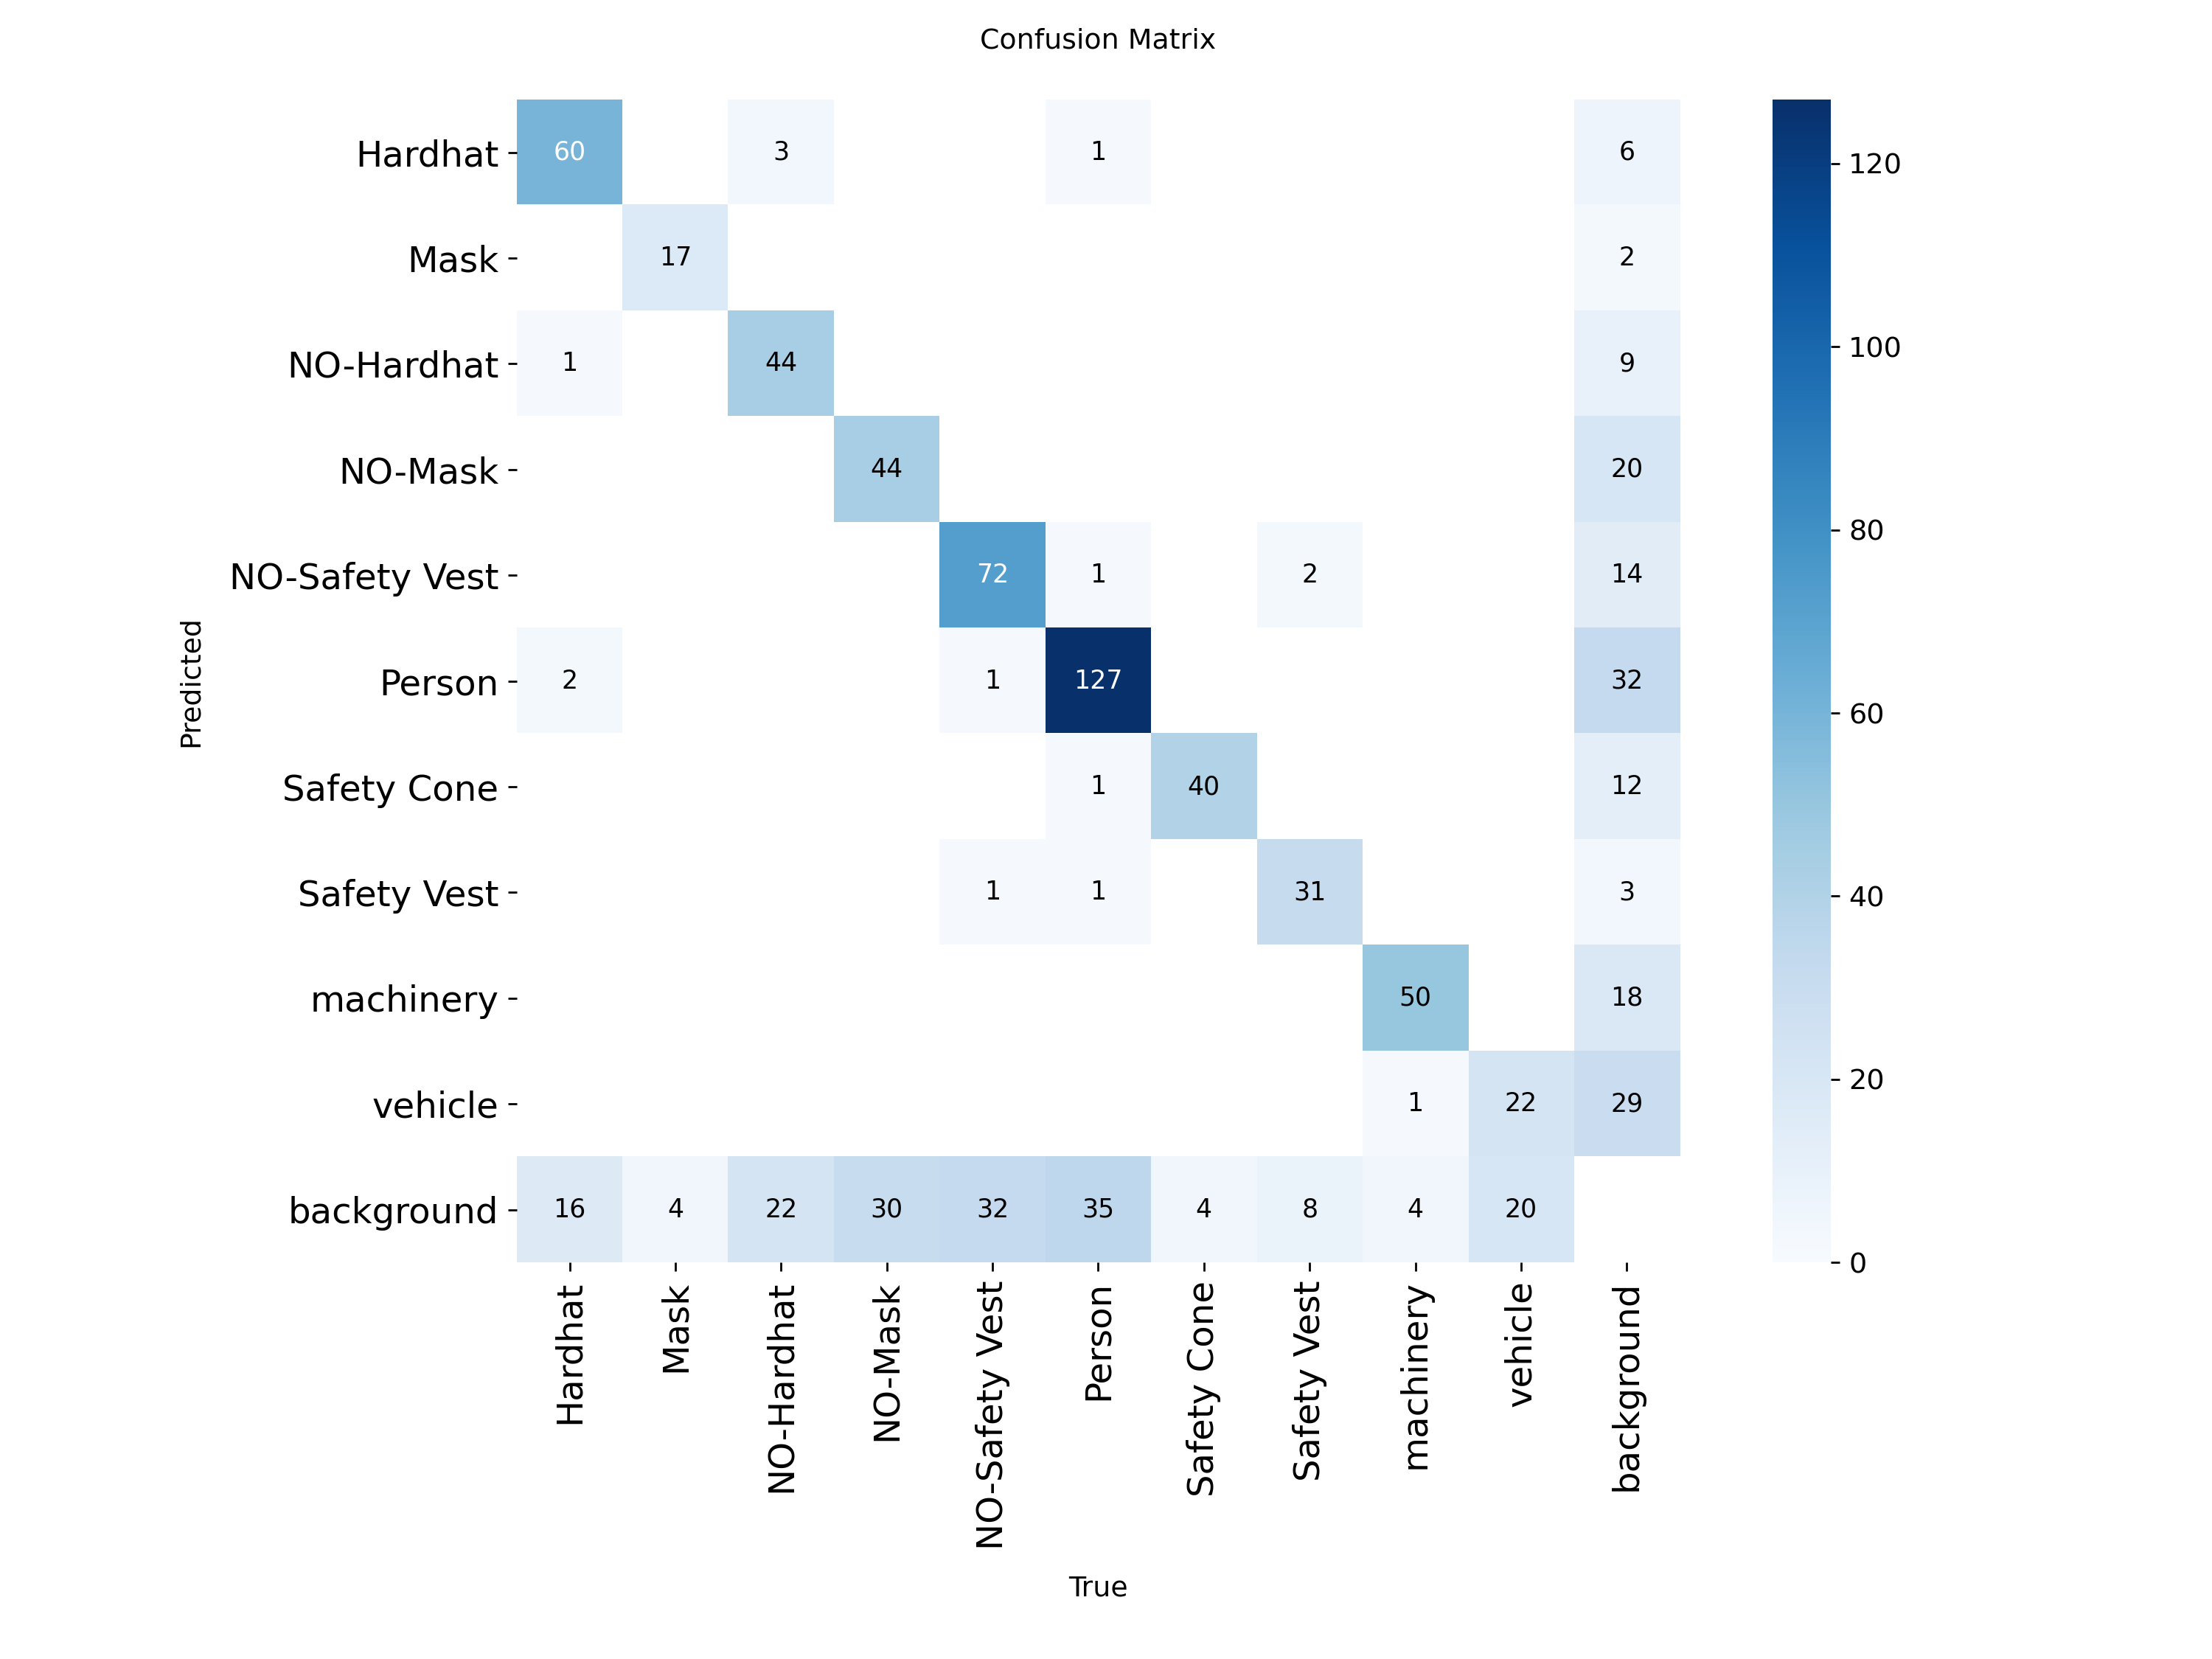

**confusion_matrix.png**  
`/content/runs/detect/val-2/confusion_matrix.png`

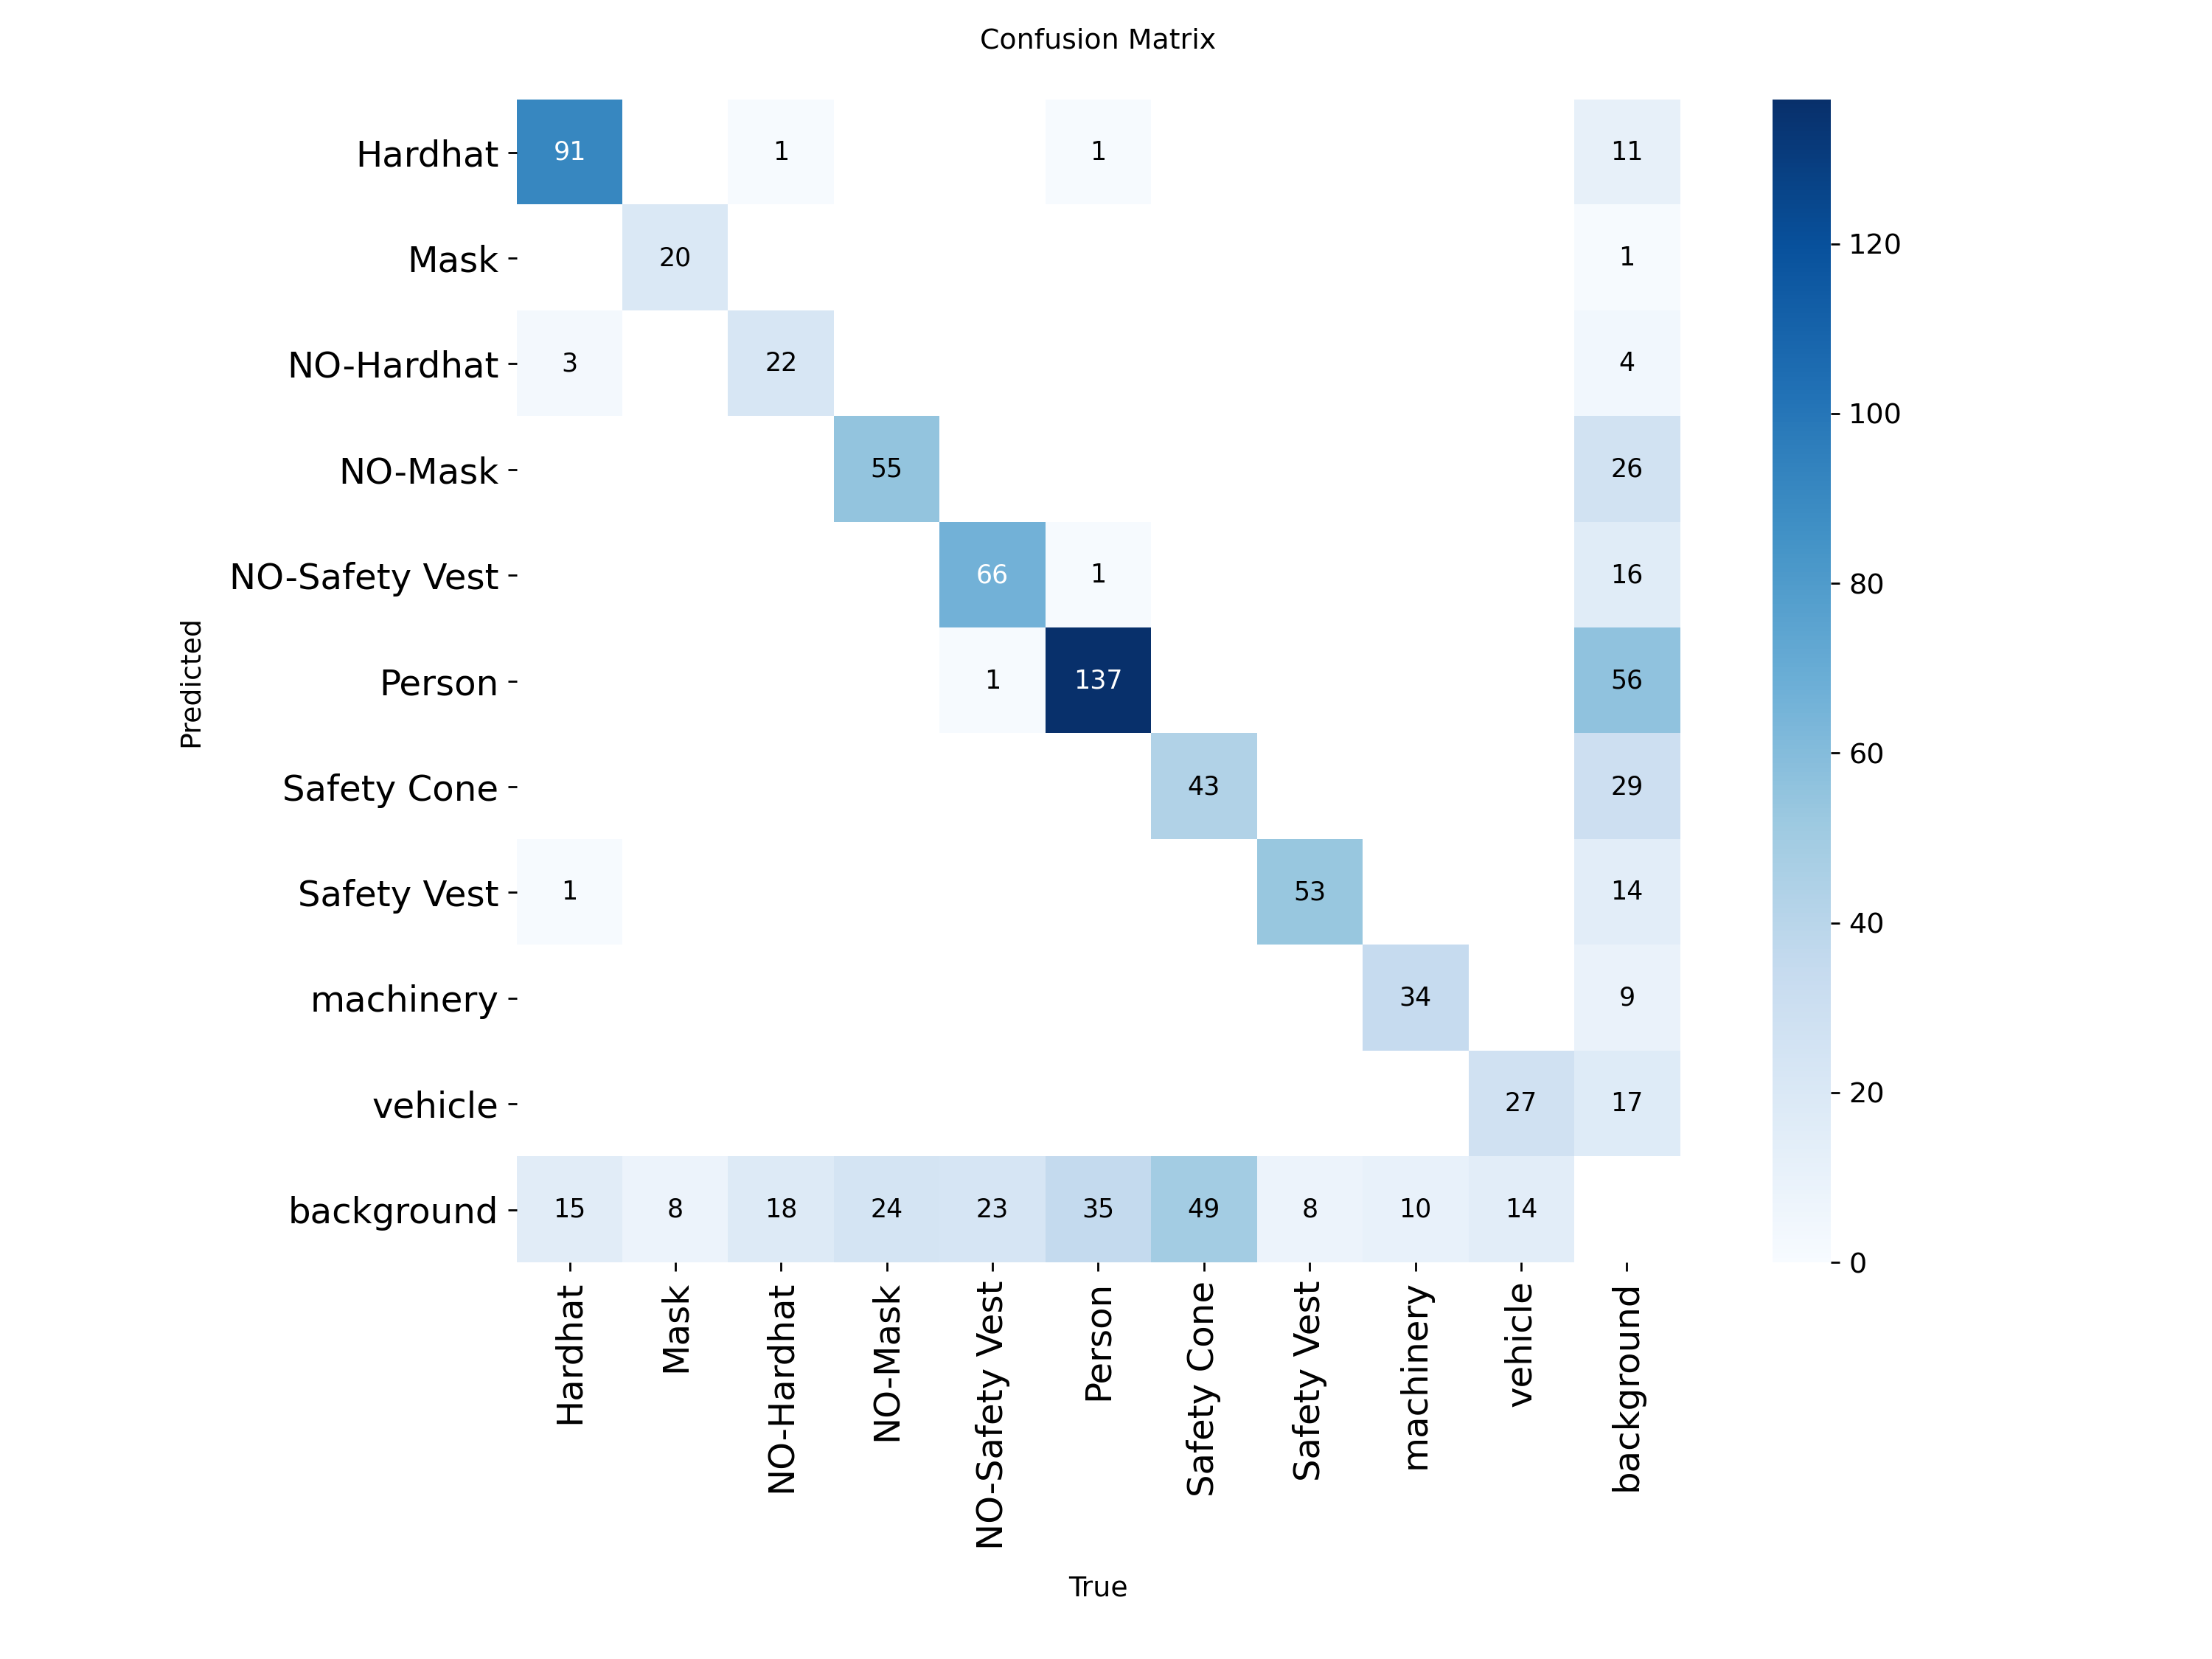

**results.png**  
`/content/drive/MyDrive/construction-safety-ppe/yolo_runs/ppe_yolov8n_baseline/results.png`

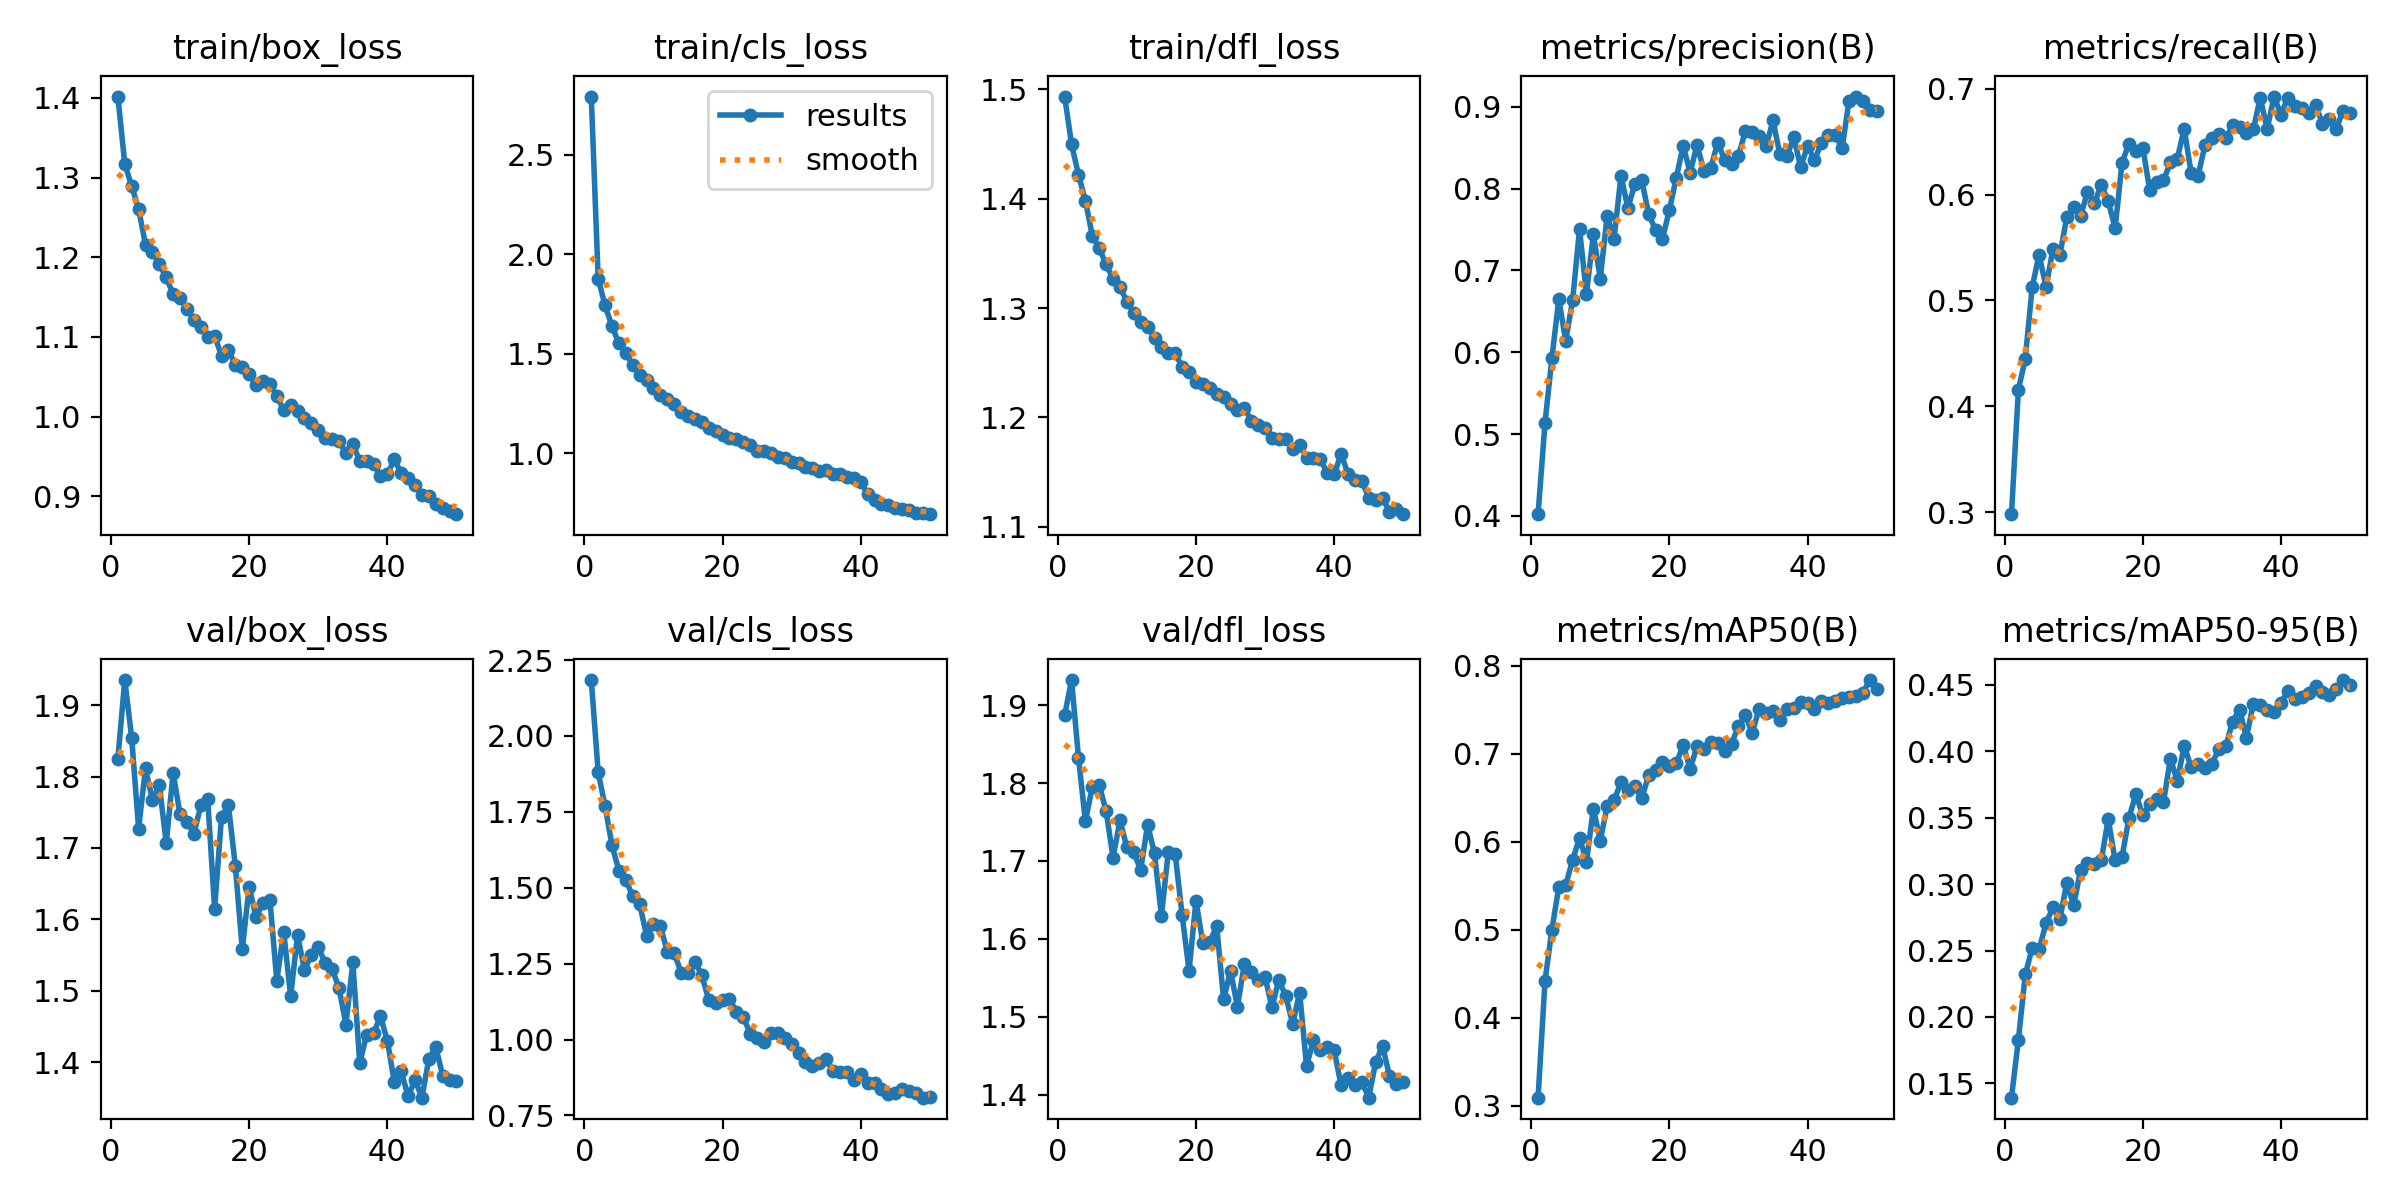

**confusion_matrix.png**  
`/content/drive/MyDrive/construction-safety-ppe/yolo_runs/ppe_yolov8n_baseline/confusion_matrix.png`

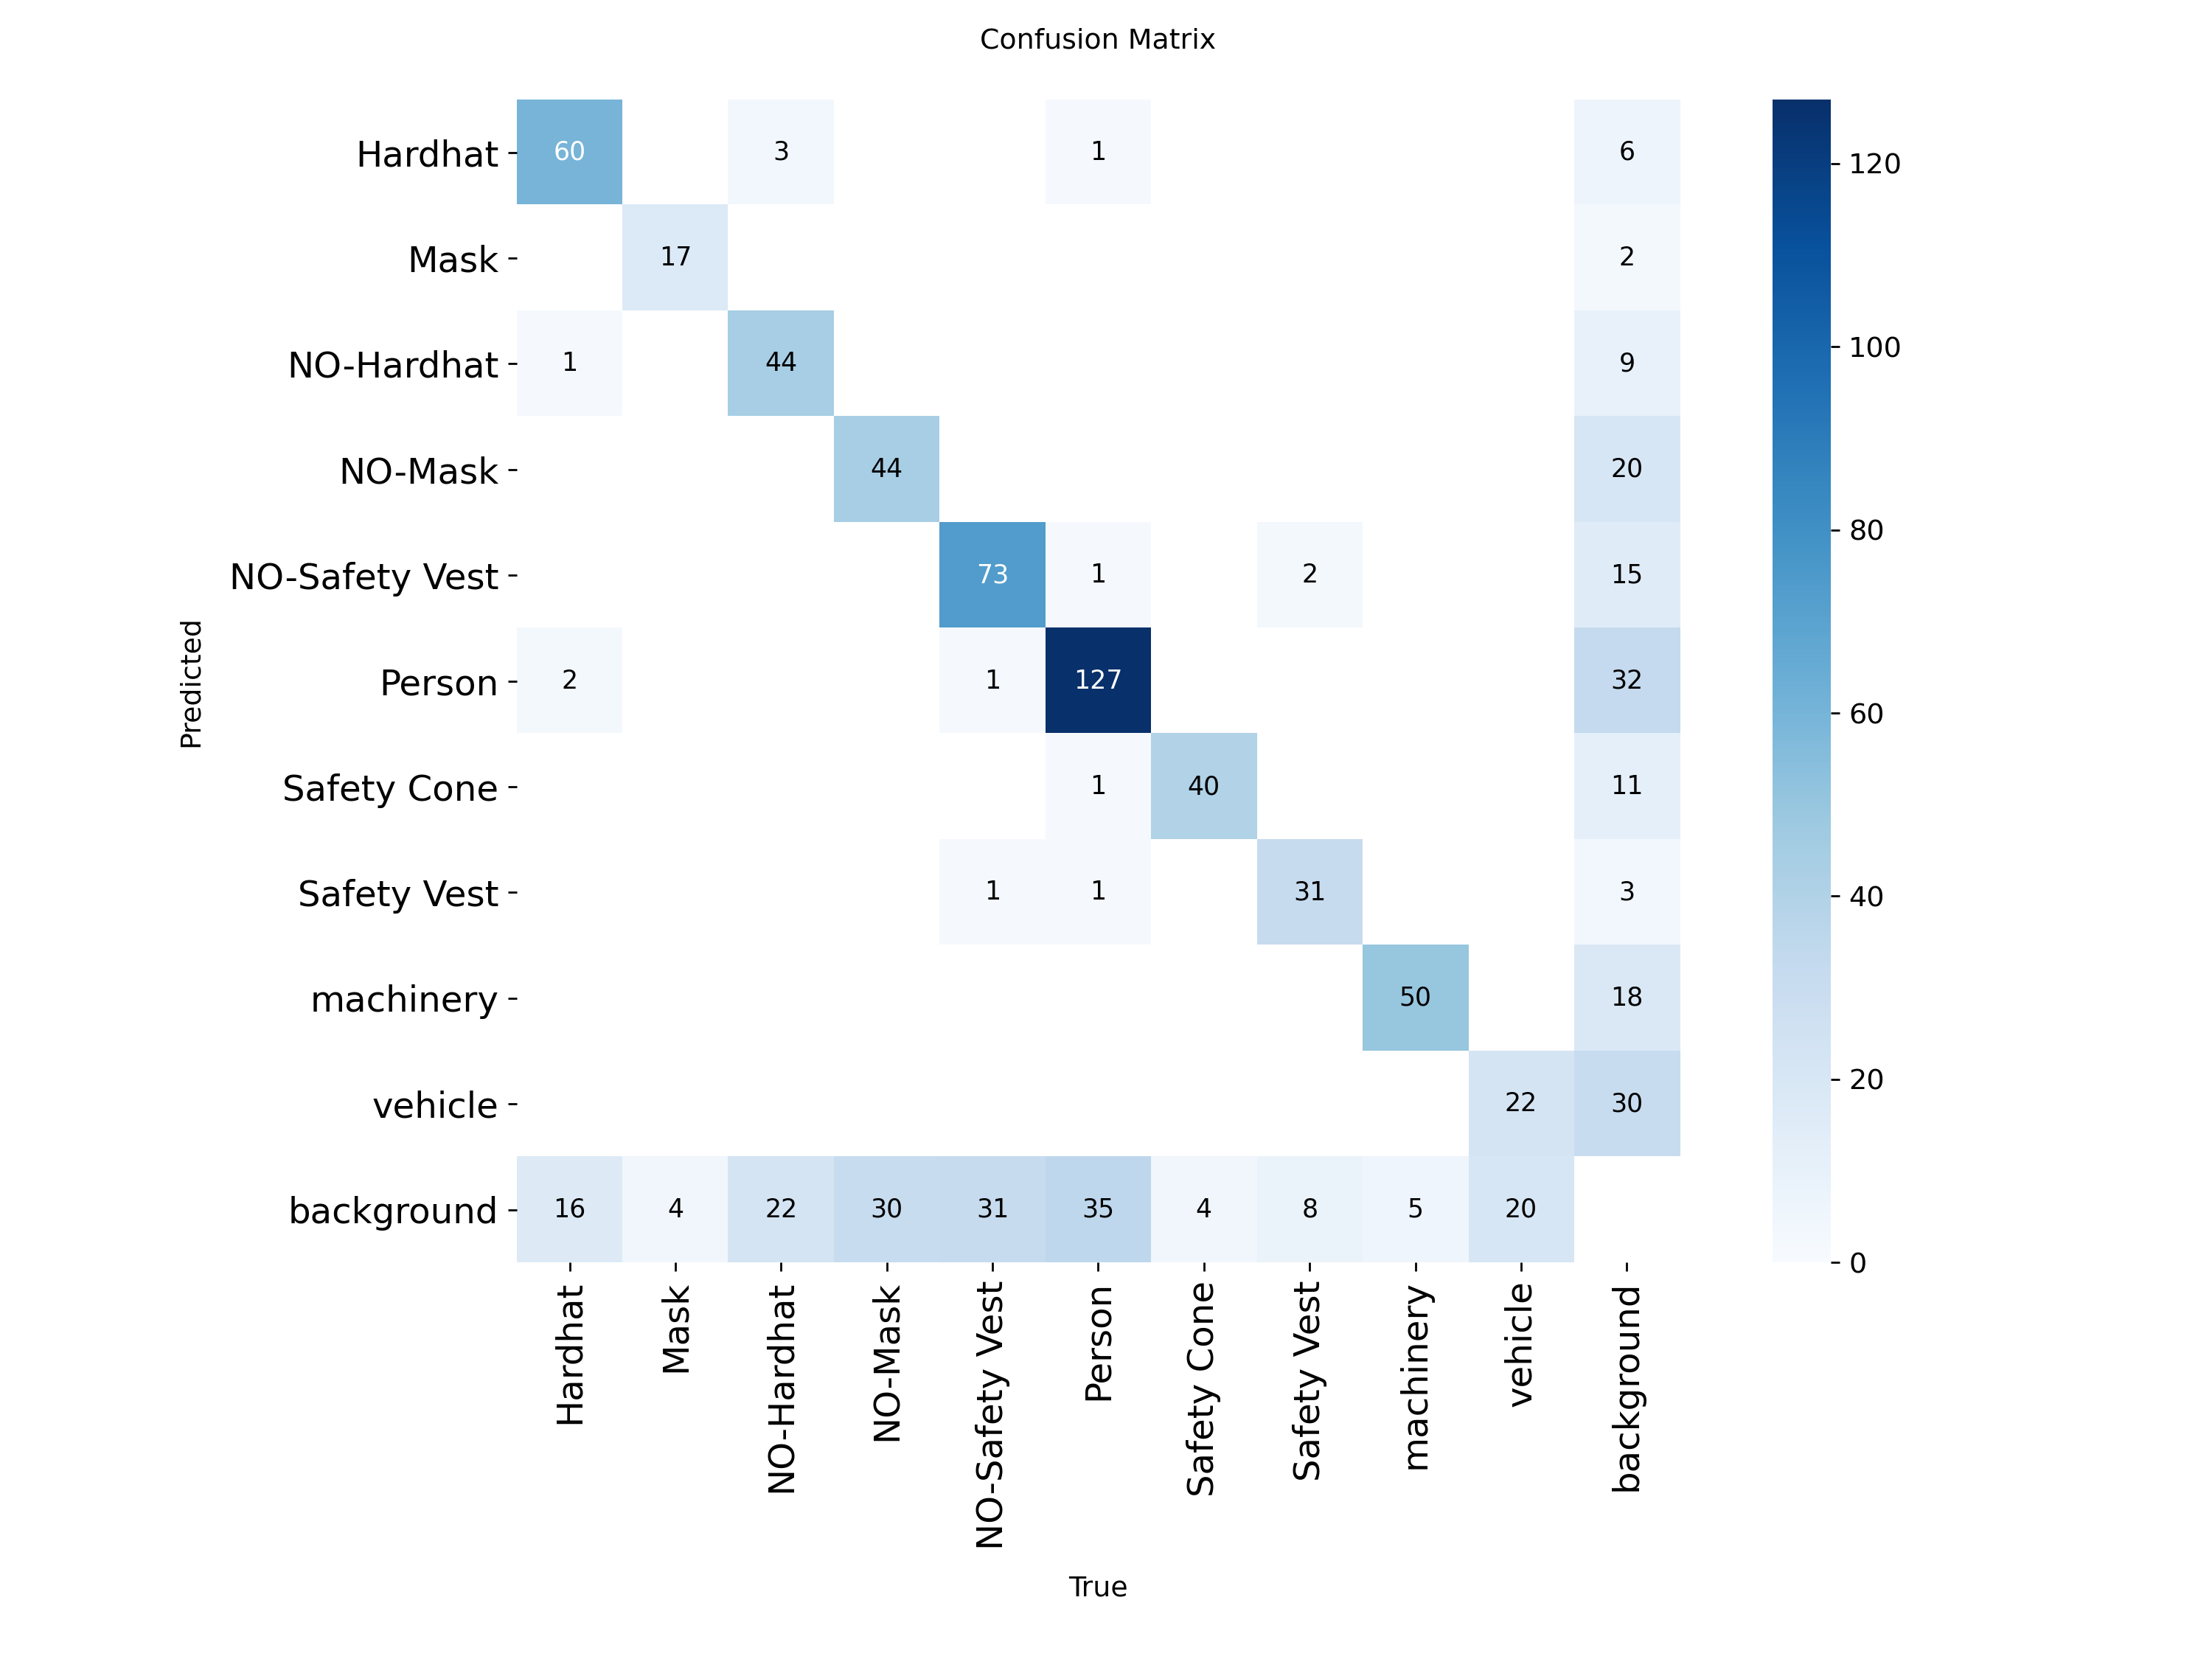

**maksssksksss17_png_jpg.rf.f685b497756b1facbf3d4c2d2d22c0d2.jpg**  
`/content/drive/MyDrive/construction-safety-ppe/predictions/sample_compliance/maksssksksss17_png_jpg.rf.f685b497756b1facbf3d4c2d2d22c0d2.jpg`

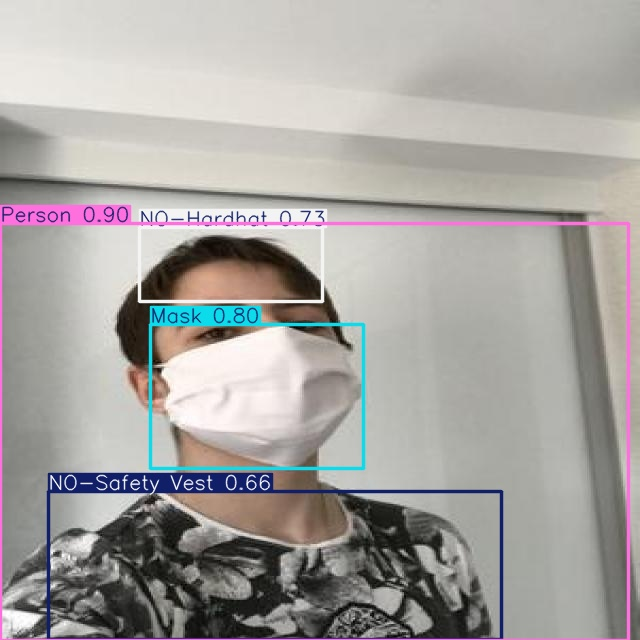

**youtube-198_jpg.rf.e89faeb9765c6bd6cece5434d140f4af.jpg**  
`/content/drive/MyDrive/construction-safety-ppe/predictions/sample_compliance/youtube-198_jpg.rf.e89faeb9765c6bd6cece5434d140f4af.jpg`

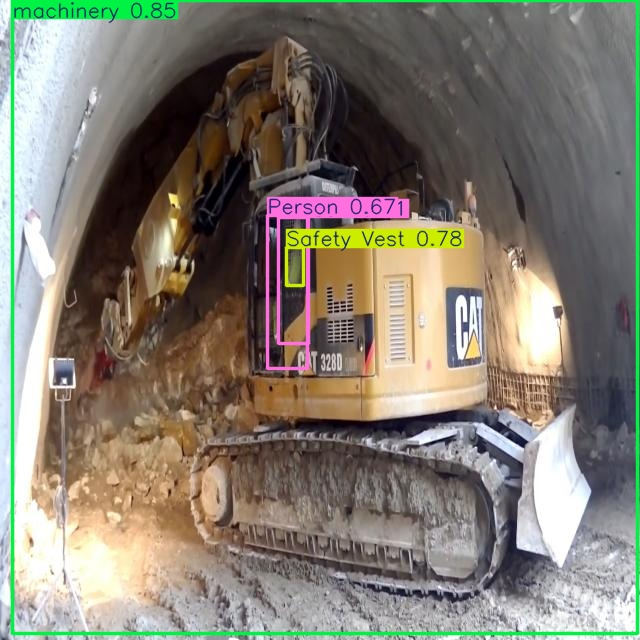

**val_batch0_pred.jpg**  
`/content/runs/detect/val/val_batch0_pred.jpg`

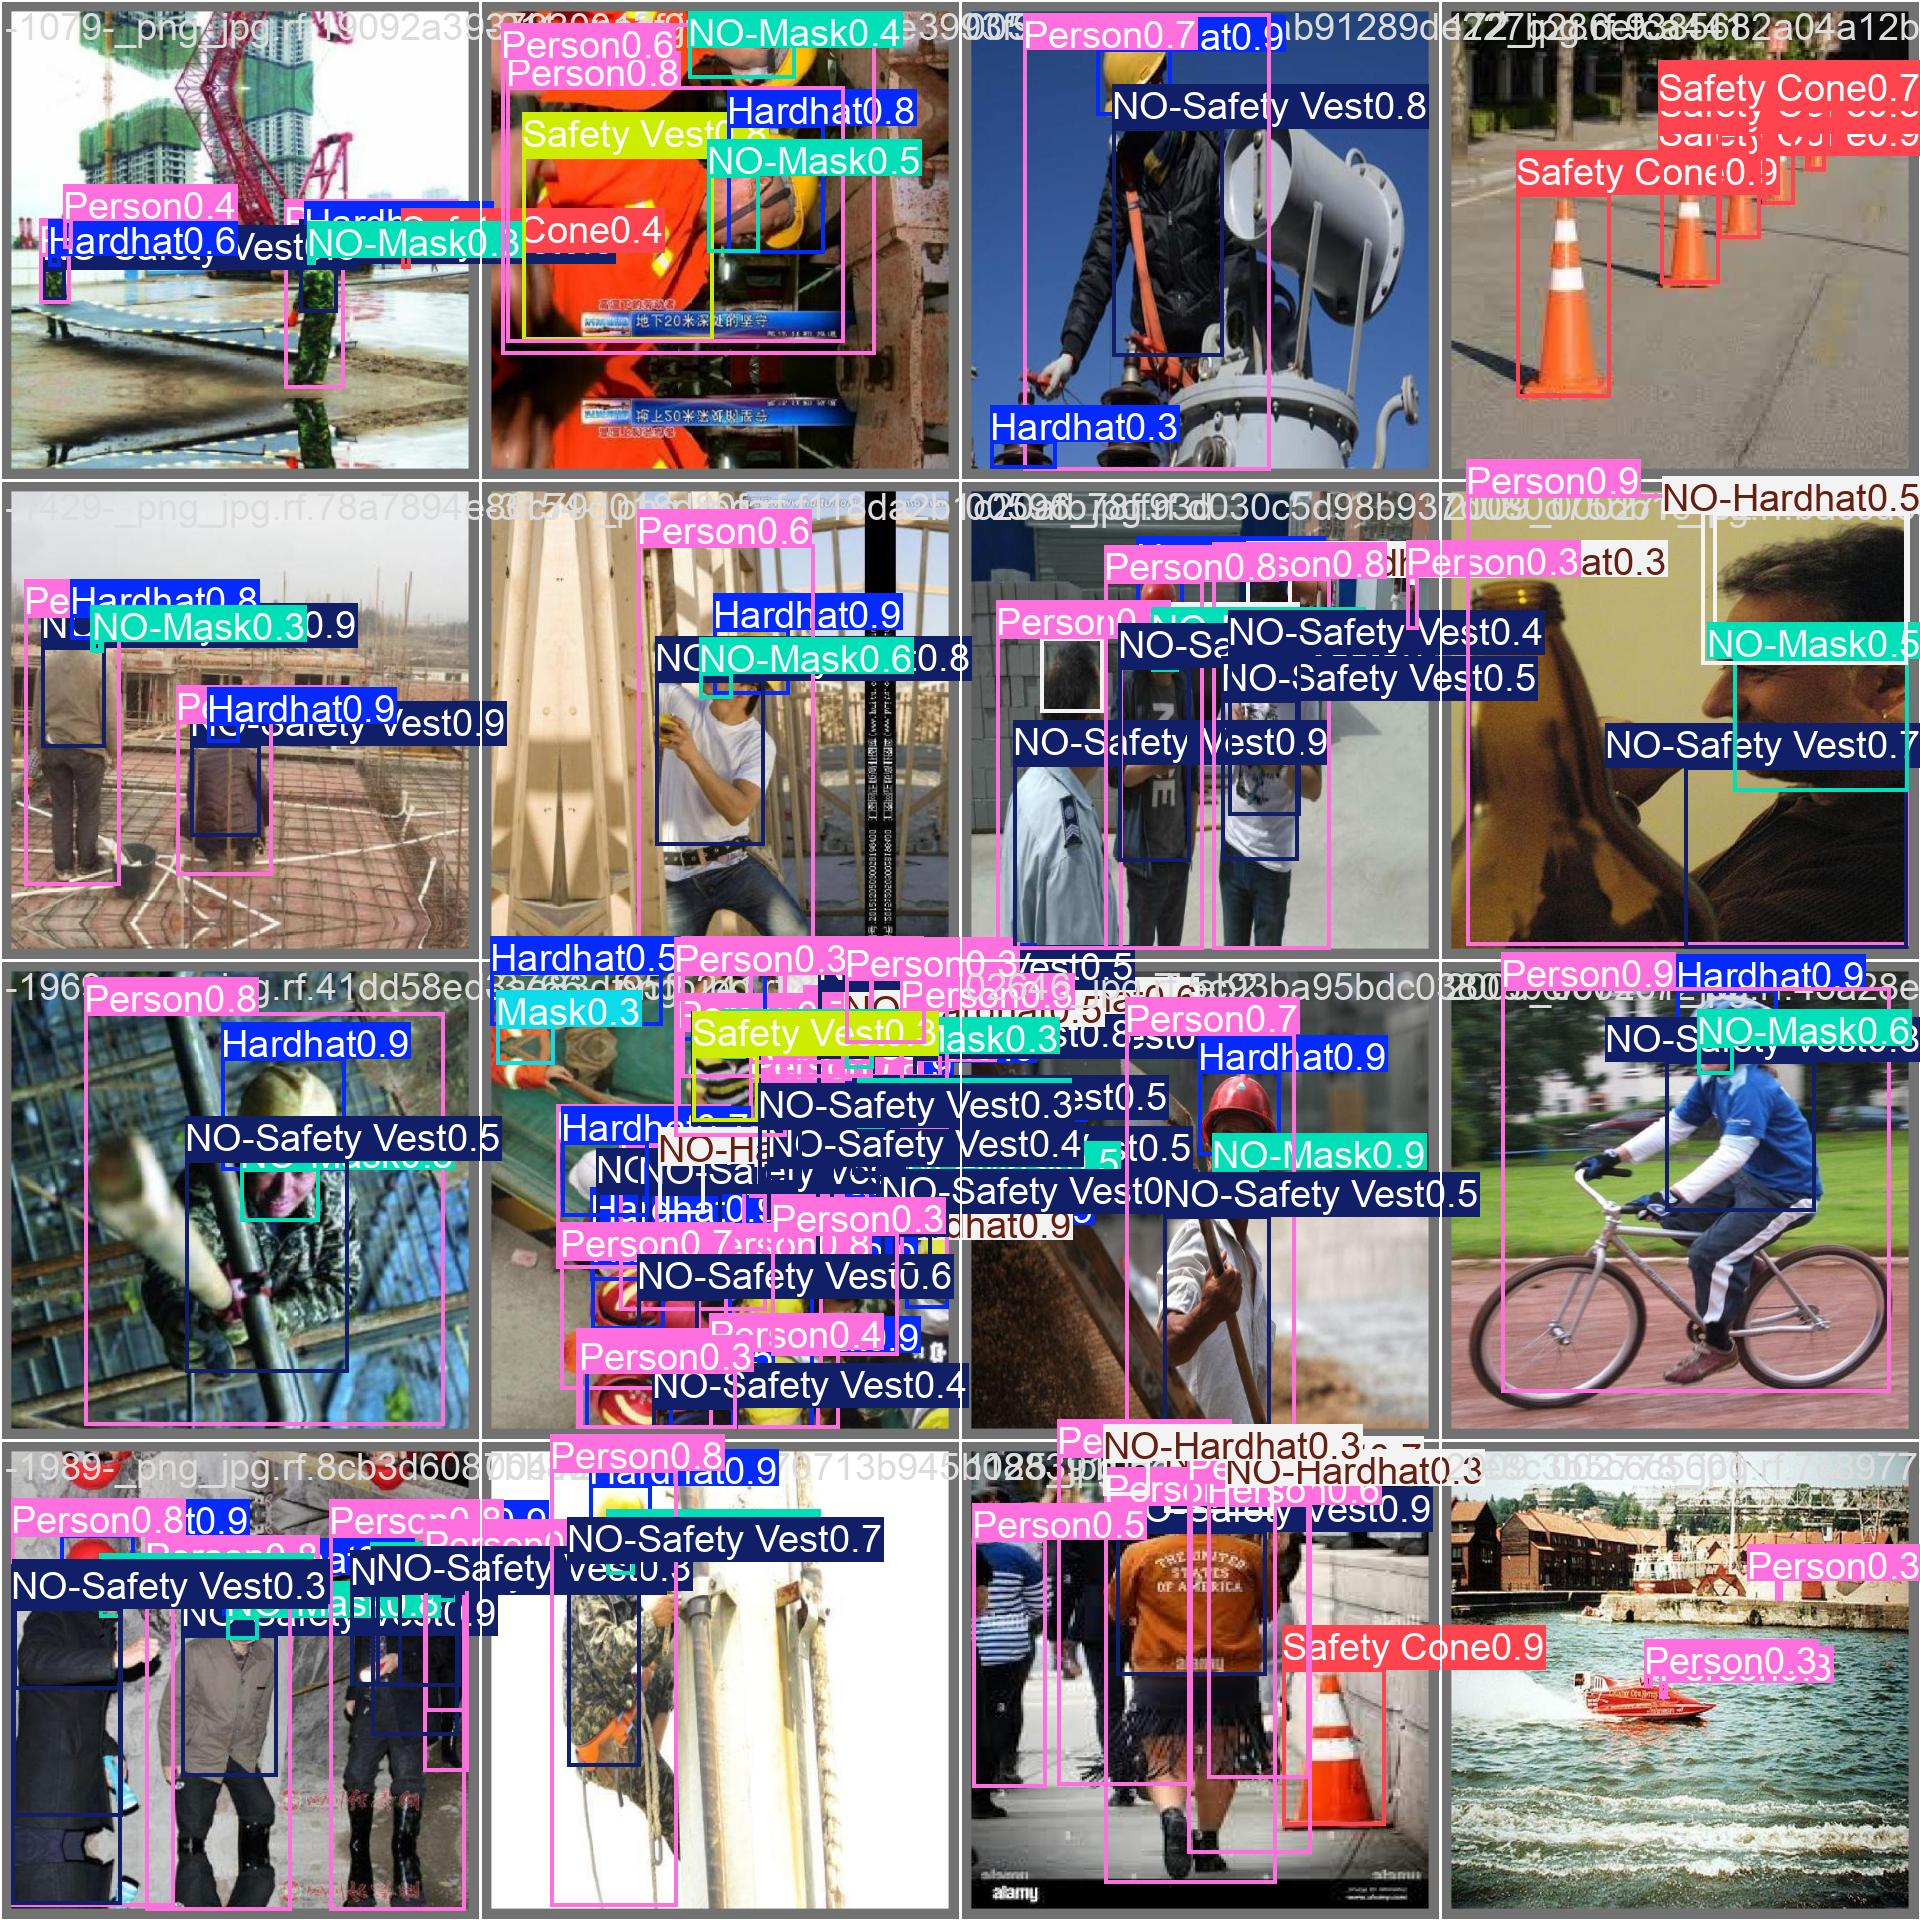

**val_batch1_pred.jpg**  
`/content/runs/detect/val/val_batch1_pred.jpg`

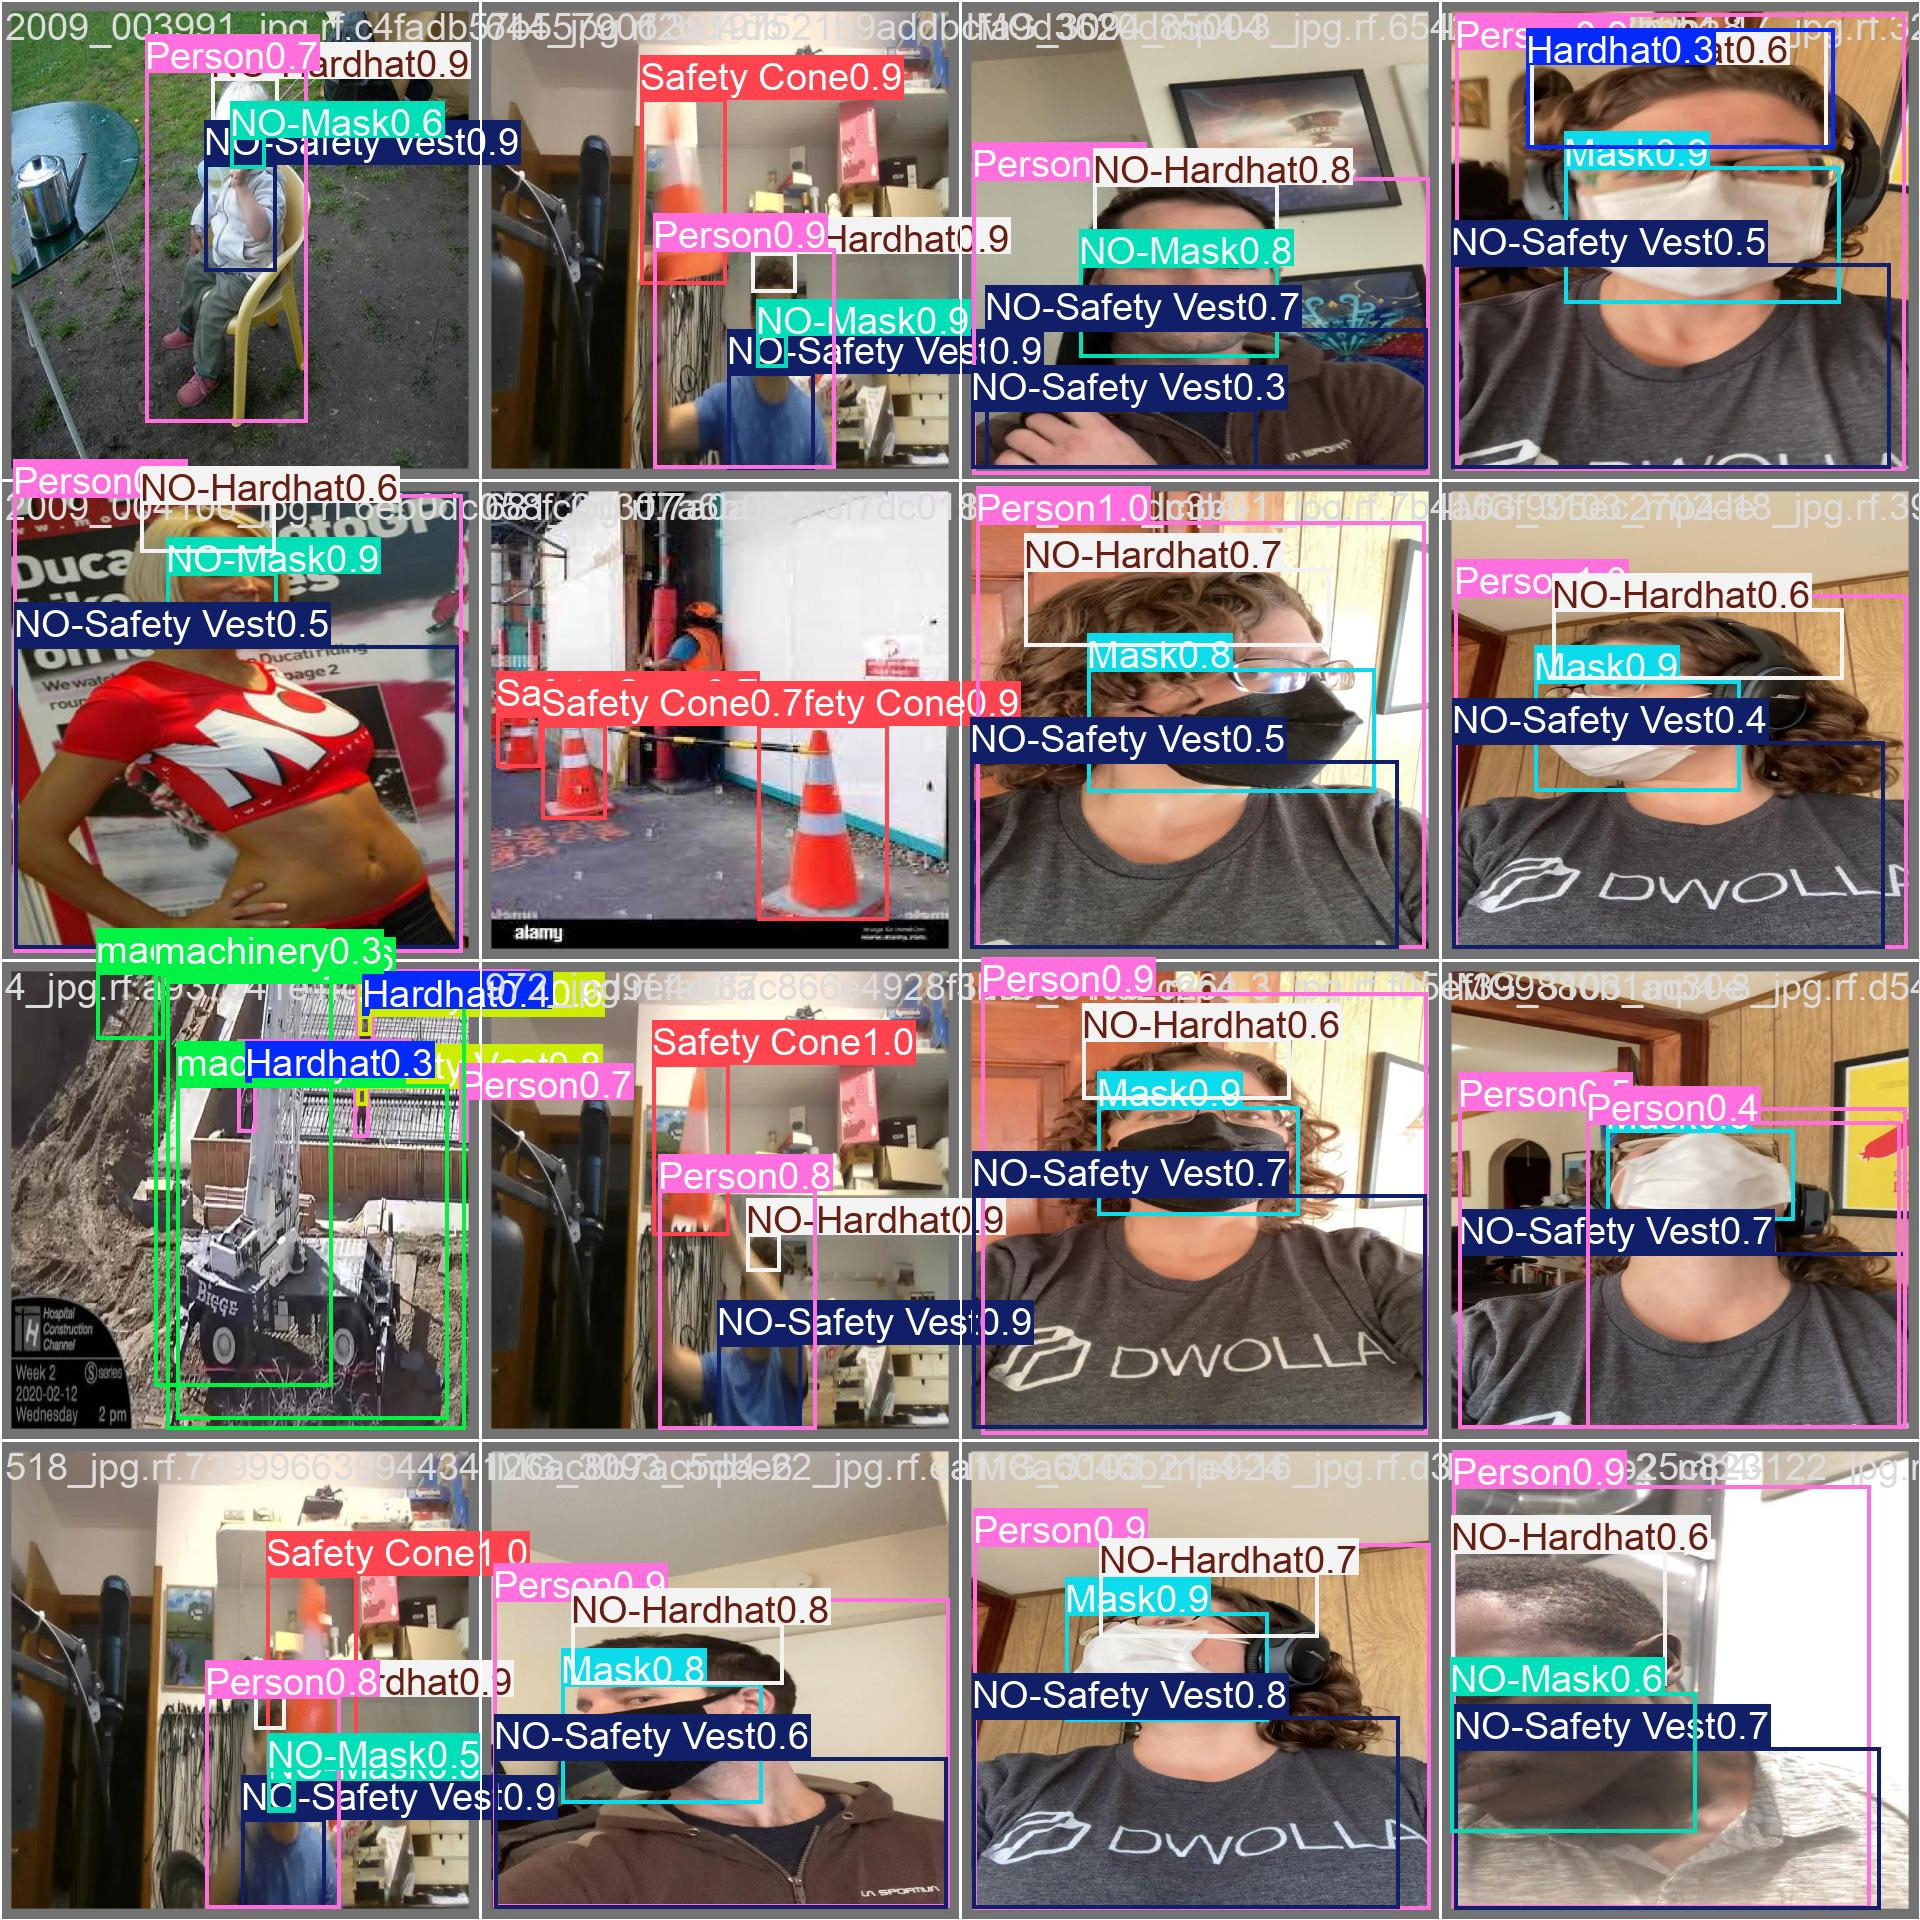

**val_batch2_pred.jpg**  
`/content/runs/detect/val/val_batch2_pred.jpg`

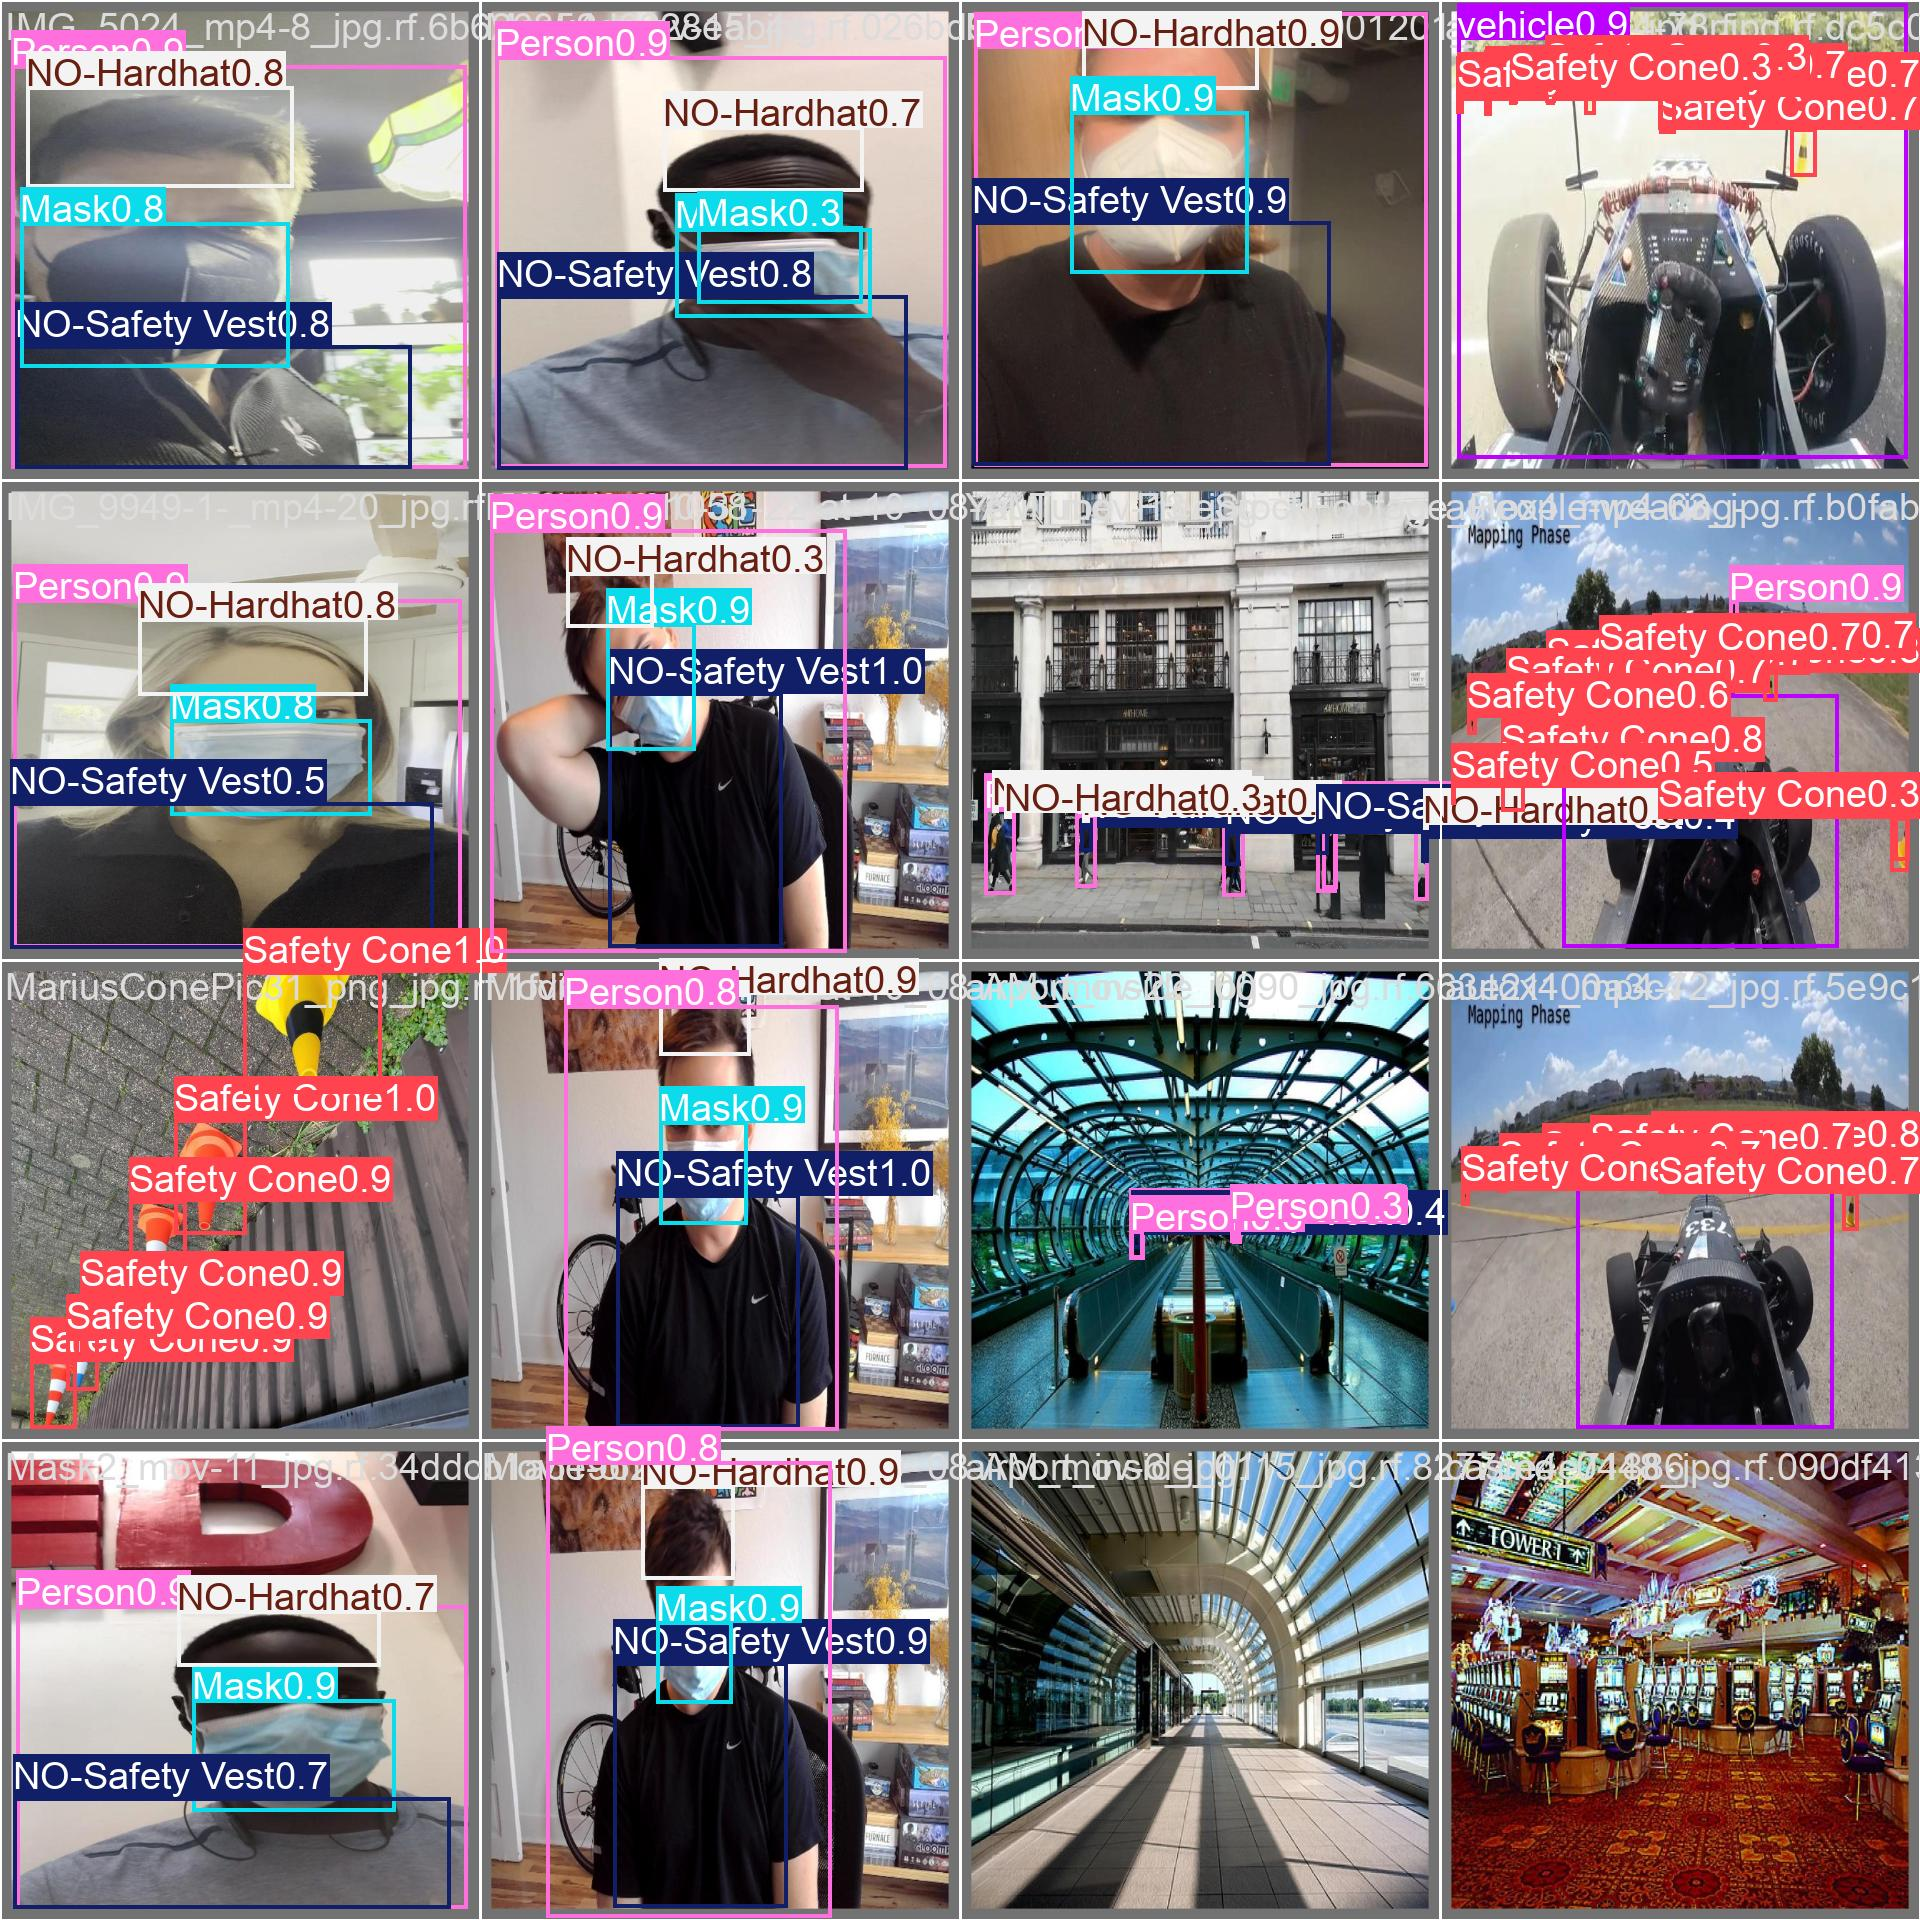

Se copiaron 37 imágenes adicionales, pero no se muestran para mantener el notebook legible.

In [8]:
from pathlib import Path
import shutil

from IPython.display import Image, Markdown, display

ARTIFACT_COPY_DIR = OUTPUT_BASE / "baseline_initial_artifacts"
ARTIFACT_COPY_DIR.mkdir(parents=True, exist_ok=True)

candidate_dirs = [
    Path("/content/outputs/yolo_runs/ppe_yolov8n_baseline"),
    Path("/content/outputs/predictions/sample_compliance"),
    Path("/content/runs/detect/val"),
    Path("/content/runs/detect/val-2"),
    OUTPUT_BASE / "yolo_runs" / "ppe_yolov8n_baseline",
    OUTPUT_BASE / "predictions" / "sample_compliance",
]

summary_artifact_names = [
    "results.png",
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
]
MAX_BATCH_EXAMPLES = 3
MAX_SAMPLE_PREDICTIONS = 2

all_images = []
summary_images = []
batch_prediction_images = []
sample_prediction_images = []

for directory in candidate_dirs:
    if not directory.exists():
        continue

    images = sorted(
        p for p in directory.rglob("*")
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    )
    all_images.extend(images)

    for artifact_name in summary_artifact_names:
        artifact = directory / artifact_name
        if artifact.exists():
            summary_images.append(artifact)

    batch_prediction_images.extend(sorted(directory.glob("val_batch*_pred.jpg")))
    if directory.name == "sample_compliance":
        sample_prediction_images.extend(sorted(directory.glob("*.jpg")))

# Remove duplicates while preserving order.
def unique_paths(paths):
    unique = []
    seen = set()
    for image_path in paths:
        resolved = str(image_path.resolve())
        if resolved not in seen:
            unique.append(image_path)
            seen.add(resolved)
    return unique

all_images = unique_paths(all_images)
summary_images = unique_paths(summary_images)
batch_prediction_images = unique_paths(batch_prediction_images)[:MAX_BATCH_EXAMPLES]
sample_prediction_images = unique_paths(sample_prediction_images)[:MAX_SAMPLE_PREDICTIONS]
images_to_display = unique_paths(summary_images + sample_prediction_images + batch_prediction_images)

print(f"Imágenes encontradas en total: {len(all_images)}")
print(f"Imágenes mostradas en resumen: {len(images_to_display)}")

for image_path in all_images:
    relative_target = ARTIFACT_COPY_DIR / image_path.parent.name / image_path.name
    relative_target.parent.mkdir(parents=True, exist_ok=True)
    try:
        shutil.copy2(image_path, relative_target)
    except shutil.SameFileError:
        pass

if not all_images:
    print("No encontre artefactos del baseline en las rutas esperadas.")
    print("Verifica que el runtime siga vivo y que exista /content/outputs/yolo_runs/ppe_yolov8n_baseline.")
else:
    display(Markdown(f"Artefactos completos copiados a `{ARTIFACT_COPY_DIR}`"))
    display(Markdown("### Resumen visual mostrado"))
    for image_path in images_to_display:
        display(Markdown(f"**{image_path.name}**  \n`{image_path}`"))
        display(Image(filename=str(image_path)))

    hidden_count = len(all_images) - len(images_to_display)
    if hidden_count > 0:
        display(Markdown(f"Se copiaron {hidden_count} imágenes adicionales, pero no se muestran para mantener el notebook legible."))


### Cómo leer los artefactos visuales de la línea base

La celda anterior encontró 66 imágenes generadas por Ultralytics y mostró solo 11 para mantener el notebook legible. Estas son las piezas importantes y cómo interpretarlas:

- **`results.png`**: resume el entrenamiento por epoca. Las pérdidas (`box_loss`, `cls_loss`, `dfl_loss`) deberían bajar o estabilizarse. Las métricas (`precisión`, `recall`, `mAP50`, `mAP50-95`) deberían subir. En este línea base, el modelo aprendio de forma razonable, pero el recall quedó como el punto debil.

- **`confusion_matrix.png`**: muestra en que clases se confunde el detector. Es especialmente importante revisar las filas/columnas de `NO-Hardhat`, `NO-Mask` y `NO-Safety Vest`, porque esos errores afectan directamente la detección de incumplimientos.

- **`PR_curve.png`**: muestra la relacion entre precisión y recall. Para una aplicación de seguridad, no basta con precisión alta; necesitamos recall alto en las clases `NO-*`, aunque eso pueda aumentar algunos falsos positivos.

- **`F1_curve.png`**: ayuda a elegir un umbral de confianza equilibrado. El umbral óptimo para métricas generales puede no ser el mejor para seguridad. Por eso más adelante usamos `COMPLIANCE_CONFIDENCE = 0.15`, buscando detectar más posibles incumplimientos y mandar casos dudosos a revisión.

- **`sample_compliance/*.jpg`**: son ejemplos individuales con cajas predichas. Sirven para validar que el sistema produce una salida entendible: persona detectada, EPP detectado e incumplimientos como `NO-Hardhat` o `NO-Safety Vest`.

- **`val_batch*_pred.jpg`**: muestran lotes de validación con predicciones del modelo. Son útiles para detectar patrones de fallo: objetos pequeños, oclusiones, trabajadores parcialmente visibles, cascos/chalecos confundidos o cajas mal localizadas.

Lectura general del intento inicial: el modelo `yolov8n` ya sirve como línea base operativo porque entrega detecciones explicables, pero todavía necesita mejorar recall en incumplimientos. El siguiente experimento con `yolov8s` apunta justamente a reducir falsos negativos en las clases `NO-*`.

## 9. Experimento mejorado: YOLOv8s con persistencia en Drive

Este experimento usa un modelo más grande que `yolov8n`. La meta no es solo subir accuracy global, sino mejorar detección de incumplimientos. En seguridad laboral conviene tolerar algunos falsos positivos si eso reduce falsos negativos peligrosos.

Recomendacion: ejecuta esta sección en Colab con GPU. Los resultados se guardan en `OUTPUT_BASE`, que ahora apunta a Google Drive cuando `USE_GOOGLE_DRIVE = True`.

In [9]:
IMPROVED_MODEL_WEIGHTS = "yolov8s.pt"
IMPROVED_RUN_NAME = "ppe_yolov8s_recall_focus"
IMPROVED_EPOCHS = 75
IMPROVED_BATCH_SIZE = 16 if torch.cuda.is_available() else 4
RUN_IMPROVED_TRAINING = False

if RUN_IMPROVED_TRAINING:
    improved_model = YOLO(IMPROVED_MODEL_WEIGHTS)
    improved_train_results = improved_model.train(
        data=str(DATA_YAML_PATH),
        epochs=IMPROVED_EPOCHS,
        imgsz=IMG_SIZE,
        batch=IMPROVED_BATCH_SIZE,
        device=DEVICE,
        project=str((OUTPUT_BASE / "yolo_runs").resolve()),
        name=IMPROVED_RUN_NAME,
        exist_ok=True,
        patience=20,
        seed=42,
        cache=True,
        plots=True,
        cos_lr=True,
        close_mosaic=10,
    )
else:
    print("RUN_IMPROVED_TRAINING=False. Cambialo a True para entrenar el modelo mejorado.")

RUN_IMPROVED_TRAINING=False. Cambialo a True para entrenar el modelo mejorado.


In [10]:
RUN_IMPROVED_EVALUATION = True

if RUN_IMPROVED_EVALUATION:
    improved_model_path = OUTPUT_BASE / "yolo_runs" / IMPROVED_RUN_NAME / "weights" / "best.pt"
    if not improved_model_path.exists():
        raise FileNotFoundError(
            f"No existe {improved_model_path}. Ejecuta primero el entrenamiento mejorado."
        )

    improved_eval_model = YOLO(str(improved_model_path))

    print("Validación modelo mejorado:")
    improved_val_metrics = improved_eval_model.val(
        data=str(DATA_YAML_PATH),
        split="val",
        imgsz=IMG_SIZE,
        device=DEVICE,
        project=str((OUTPUT_BASE / "yolo_eval").resolve()),
        name=f"{IMPROVED_RUN_NAME}_val",
        exist_ok=True,
    )

    print("Test modelo mejorado:")
    improved_test_metrics = improved_eval_model.val(
        data=str(DATA_YAML_PATH),
        split="test",
        imgsz=IMG_SIZE,
        device=DEVICE,
        project=str((OUTPUT_BASE / "yolo_eval").resolve()),
        name=f"{IMPROVED_RUN_NAME}_test",
        exist_ok=True,
    )
else:
    print("RUN_IMPROVED_EVALUATION=False. Cambialo a True para evaluar el modelo mejorado.")

Validación modelo mejorado:
Ultralytics 8.4.55 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1578.9±608.4 MB/s, size: 39.8 KB)
val: Scanning /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data/valid/labels.cache... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 29.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.0it/s 4.0s0.3ss
                   all        114        697      0.906      0.779      0.849      0.566
               Hardhat         42         79      0.915      0.814      0.895      0.618
                  Mask         19         21      0.971      0.905      0.905      0.718
            NO-Hardhat         37         69      0.903      0.609      0.761      0.436
        

### Comentario sobre la evaluación del modelo mejorado

El modelo mejorado `yolov8s` muestra una mejora clara frente al línea base `yolov8n`, especialmente en recall y calidad de cajas.

Comparación global en test:

| modelo | precisión | recall | mAP50 | mAP50-95 |
|---|---:|---:|---:|---:|
| YOLOv8n línea base | 0.861 | 0.662 | 0.721 | 0.409 |
| YOLOv8s mejorado | 0.898 | 0.737 | 0.784 | 0.508 |

Lectura practica:

- El `yolov8s` detecta más objetos reales: el recall sube de 0.662 a 0.737 en test.
- También localiza mejor: `mAP50-95` sube de 0.409 a 0.508.
- El costo computacional aumenta: el modelo pasa de unas 3.0M de parámetros a 11.1M, pero sigue siendo razonable para GPU.

Clases críticas de incumplimiento en test:

| clase | recall línea base | recall YOLOv8s | lectura |
|---|---:|---:|---|
| NO-Hardhat | 0.537 | 0.576 | mejora leve, sigue siendo la clase critica más debil |
| NO-Mask | 0.587 | 0.732 | mejora fuerte, mucho mejor para seguridad |
| NO-Safety Vest | 0.722 | 0.733 | mejora leve en recall y mejora fuerte en caja/mAP |

Conclusión: `yolov8s` es mejor candidato que `yolov8n` para la aplicación real. Todavía hay que trabajar `NO-Hardhat`, porque sigue omitiendo demasiados casos sin casco.

In [11]:
import pandas as pd

runs_dir = OUTPUT_BASE / "yolo_runs"
result_files = sorted(runs_dir.glob("*/results.csv"))

if not result_files:
    print("No hay archivos results.csv aun.")
else:
    summaries = []
    for result_file in result_files:
        results_df = pd.read_csv(result_file)
        last_row = results_df.tail(1).copy()
        last_row.insert(0, "run", result_file.parent.name)
        summaries.append(last_row)

    comparison_df = pd.concat(summaries, ignore_index=True)
    metric_columns = [
        col for col in comparison_df.columns
        if "metrics/precision" in col
        or "metrics/recall" in col
        or "metrics/mAP50" in col
        or col in {"run", "epoch"}
    ]
    display(comparison_df[metric_columns])

,run,epoch,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
0,ppe_yolov8n_baseline,50,0.89548,0.67715,0.77395,0.44986
1,ppe_yolov8s_recall_focus,75,0.87811,0.80395,0.84078,0.55990


### Comentario sobre la comparación de entrenamientos

La tabla de `results.csv` confirma el cambio que buscábamos: el modelo mejorado sacrifica un poco de precisión final de entrenamiento, pero gana mucho recall.

| run | precisión | recall | mAP50 | mAP50-95 |
|---|---:|---:|---:|---:|
| ppe_yolov8n_baseline | 0.895 | 0.677 | 0.774 | 0.450 |
| ppe_yolov8s_recall_focus | 0.878 | 0.804 | 0.841 | 0.560 |

Para seguridad industrial, este intercambio es bueno: preferimos detectar más posibles incumplimientos aunque algunos casos requieran revisión humana. La mejora de recall de 0.677 a 0.804 es el avance más importante de este paso.

### Análisis de errores y mejoras basadas en hallazgos

El análisis de resultados muestra que el cambio de `yolov8n` a `yolov8s` mejora el desempeño global y especialmente el recall. Sin embargo, los errores no se distribuyen igual entre clases.

Errores más relevantes:

- `NO-Hardhat` sigue siendo la clase critica más debil. Su recall mejora, pero aun puede omitir personas sin casco.
- `NO-Mask` mejora de forma clara con `yolov8s`, lo que indica que el línea base tenia capacidad limitada para esta clase.
- `Safety Cone` tiene bajo recall en test, posiblemente por objetos pequeños, repetidos o parcialmente visibles.
- Las imágenes con maquinaria grande o trabajadores pequeños pueden inducir cajas incompletas o confusiones.

Implicacion para seguridad:

Un falso positivo puede generar revisión innecesaria, pero un falso negativo puede dejar pasar una condición insegura. Por eso, para despliegue real se recomienda calibrar umbrales por clase y priorizar recall en `NO-Hardhat`, `NO-Mask` y `NO-Safety Vest`.

Mejoras propuestas:

- Revisar visualmente falsos negativos de `NO-Hardhat` y enriquecer datos de esa clase.
- Probar `yolov8m` o un modelo más reciente si hay GPU disponible.
- Ajustar umbrales de confianza por clase para la capa de cumplimiento.
- Agregar imágenes reales de obra no vistas para una prueba externa de generalizacion.
- Mejorar la asociacion persona-EPP usando IoU, distancia relativa por region corporal o tracking si se usa video.


## 10. Inferencia conservadora para cumplimiento

Para el reporte operativo, se puede usar un umbral de confianza más bajo que el default cuando buscamos infracciones `NO-*`. Esto aumenta recall y manda más casos a revisión. En seguridad suele ser preferible revisar algunos falsos positivos antes que omitir una infraccion real.

In [12]:
COMPLIANCE_CONFIDENCE = 0.15
PREFERRED_RUN_NAME = IMPROVED_RUN_NAME
preferred_model_path = OUTPUT_BASE / "yolo_runs" / PREFERRED_RUN_NAME / "weights" / "best.pt"

if not preferred_model_path.exists():
    print(f"No existe {preferred_model_path}. Usando baseline si esta disponible.")
    preferred_model_path = OUTPUT_BASE / "yolo_runs" / "ppe_yolov8n_baseline" / "weights" / "best.pt"

if not preferred_model_path.exists():
    raise FileNotFoundError("No hay pesos entrenados disponibles para inferencia de cumplimiento.")

compliance_model = YOLO(str(preferred_model_path))
sample_image = next((DATASET_ROOT / "test" / "images").glob("*.jpg"))

results = compliance_model.predict(
    source=str(sample_image),
    imgsz=IMG_SIZE,
    conf=COMPLIANCE_CONFIDENCE,
    device=DEVICE,
    save=True,
    project=str((OUTPUT_BASE / "predictions").resolve()),
    name=f"compliance_conf_{str(COMPLIANCE_CONFIDENCE).replace('.', '_')}",
    exist_ok=True,
)

result = results[0]
detections = []
for box in result.boxes:
    class_id = int(box.cls.item())
    detections.append(
        Detection(
            class_name=result.names[class_id],
            confidence=float(box.conf.item()),
            box_xyxy=tuple(float(value) for value in box.xyxy[0].tolist()),
        )
    )

report = generate_ppe_compliance_report(detections, min_confidence=COMPLIANCE_CONFIDENCE)
print("Modelo usado:", preferred_model_path)
print("Umbral de cumplimiento:", COMPLIANCE_CONFIDENCE)
print("Imagen:", sample_image)
print("Reporte de cumplimiento:")
if hasattr(report, "__dataclass_fields__"):
    pprint(asdict(report))
else:
    pprint(report)


image 1/1 /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data/test/images/maksssksksss17_png_jpg.rf.f685b497756b1facbf3d4c2d2d22c0d2.jpg: 640x640 1 Mask, 1 NO-Hardhat, 2 NO-Safety Vests, 1 Person, 16.2ms
Speed: 2.1ms preprocess, 16.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/construction-safety-ppe/predictions/compliance_conf_0_15
Modelo usado: /content/drive/MyDrive/construction-safety-ppe/yolo_runs/ppe_yolov8s_recall_focus/weights/best.pt
Umbral de cumplimiento: 0.15
Imagen: /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data/test/images/maksssksksss17_png_jpg.rf.f685b497756b1facbf3d4c2d2d22c0d2.jpg
Reporte de cumplimiento:
{'person_count': 1,
 'persons': [{'detected_ppe': ('Mask',),
              'person_box_xyxy': (5.4246826171875,
                                  224.4588623046875,
             

### Comentario sobre la inferencia conservadora

La inferencia final usó el modelo `ppe_yolov8s_recall_focus` con `COMPLIANCE_CONFIDENCE = 0.15`. Ese umbral bajo busca que el sistema sea más sensible a posibles incumplimientos.

En la imagen de ejemplo, el modelo detecto:

- 1 persona
- 1 casco (`Hardhat`)
- 1 chaleco (`Safety Vest`)
- 1 maquinaria
- 0 infracciones `NO-*`

Por eso el reporte final fue:

```text
status: sin_violaciones_detectadas
person_count: 1
violation_count: 0
```

La salida es razonable: no marca la imagen como insegura porque no detecto `NO-Hardhat`, `NO-Mask` ni `NO-Safety Vest`. Aun asi, el estado por persona queda como `requiere_revision`, porque la lógica actual solo confirma violaciones explícitas; no garantiza cumplimiento total cuando falta alguna clase esperada o hay ambigüedad visual.

Siguiente mejora lógica: diferenciar entre `cumple`, `inseguro` y `requiere_revision`. Por ejemplo, una persona con `Hardhat` y `Safety Vest` detectados podría marcarse como `cumple_epp_basico`, mientras que una persona sin evidencia clara de casco/chaleco quedaria en `requiere_revision`.

## 11. Demo interactiva del detector

Esta sección levanta una interfaz con Gradio para demostrar el modelo como una aplicación real. Tiene dos modos:

- Imagen o foto: permite subir una imagen o capturar una foto con webcam.
- Cámara en vivo: procesa frames continuos desde la webcam del navegador.

En ambos casos muestra la imagen anotada con cajas YOLO, una tabla de detecciones y un reporte de cumplimiento de EPP por persona.

La demo usa primero el modelo mejorado `ppe_yolov8s_recall_focus`. Si no encuentra esos pesos, usa la línea base `ppe_yolov8n_baseline`. En Colab, `share=True` genera un enlace temporal para mostrar la demo.


In [13]:
import importlib.util
import subprocess
import sys
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Iterable

if importlib.util.find_spec("gradio") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gradio"])

import gradio as gr
import numpy as np
import pandas as pd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

try:
    from src.ppe_compliance import Detection, generate_ppe_compliance_report
except ModuleNotFoundError:
    @dataclass(frozen=True)
    class Detection:
        class_name: str
        confidence: float
        box_xyxy: tuple[float, float, float, float]

    def _center_inside(item_box, container_box):
        x1, y1, x2, y2 = item_box
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2
        left, top, right, bottom = container_box
        return left <= cx <= right and top <= cy <= bottom

    def generate_ppe_compliance_report(
        detections: Iterable[Detection],
        *,
        person_class: str = "Person",
        ppe_classes: tuple[str, ...] = ("Hardhat", "Mask", "Safety Vest"),
        required_ppe_classes: tuple[str, ...] = ("Hardhat", "Safety Vest"),
        violation_classes: tuple[str, ...] = ("NO-Hardhat", "NO-Mask", "NO-Safety Vest"),
        min_confidence: float = 0.25,
    ):
        filtered = [det for det in detections if det.confidence >= min_confidence]
        persons = [det for det in filtered if det.class_name == person_class]
        ppe_items = [det for det in filtered if det.class_name in ppe_classes]
        violations = [det for det in filtered if det.class_name in violation_classes]

        person_reports = []
        assigned_violation_ids = set()
        for person_index, person in enumerate(persons, start=1):
            person_ppe = tuple(sorted({item.class_name for item in ppe_items if _center_inside(item.box_xyxy, person.box_xyxy)}))
            person_violations = tuple(sorted({violation.class_name for violation in violations if _center_inside(violation.box_xyxy, person.box_xyxy)}))
            for violation_id, violation in enumerate(violations):
                if violation.class_name in person_violations and _center_inside(violation.box_xyxy, person.box_xyxy):
                    assigned_violation_ids.add(violation_id)

            if person_violations:
                person_status = "inseguro"
            elif all(required_ppe in person_ppe for required_ppe in required_ppe_classes):
                person_status = "cumple_epp_basico"
            else:
                person_status = "requiere_revision"

            person_reports.append(
                {
                    "person_index": person_index,
                    "person_box_xyxy": person.box_xyxy,
                    "detected_ppe": person_ppe,
                    "violations": person_violations,
                    "status": person_status,
                }
            )

        unassigned_violations = tuple(sorted(violations[index].class_name for index in range(len(violations)) if index not in assigned_violation_ids))
        violation_count = sum(len(person["violations"]) for person in person_reports) + len(unassigned_violations)
        if violation_count:
            status = "inseguro"
        elif person_reports and all(person["status"] == "cumple_epp_basico" for person in person_reports):
            status = "cumple_epp_basico"
        else:
            status = "requiere_revision" if person_reports else "sin_personas_detectadas"

        return {
            "status": status,
            "person_count": len(person_reports),
            "violation_count": violation_count,
            "persons": person_reports,
            "unassigned_violations": unassigned_violations,
        }

model_candidates = [
    OUTPUT_BASE / "yolo_runs" / "ppe_yolov8s_recall_focus" / "weights" / "best.pt",
    OUTPUT_BASE / "yolo_runs" / "ppe_yolov8n_baseline" / "weights" / "best.pt",
]
DEMO_MODEL_PATH = next((candidate for candidate in model_candidates if candidate.exists()), None)
if DEMO_MODEL_PATH is None:
    raise FileNotFoundError(
        "No se encontró un modelo entrenado. Ejecuta primero el entrenamiento o copia best.pt a Drive."
    )

print("Modelo usado por la demo:", DEMO_MODEL_PATH)
demo_model = YOLO(str(DEMO_MODEL_PATH))

sample_examples = []
test_images_dir = DATASET_ROOT / "test" / "images"
if test_images_dir.exists():
    sample_examples = [[str(path), 0.15] for path in sorted(test_images_dir.glob("*.jpg"))[:3]]


def _predict_ppe(image, confidence):
    result = demo_model.predict(
        source=image,
        imgsz=IMG_SIZE,
        conf=float(confidence),
        device=DEVICE,
        verbose=False,
    )[0]

    annotated_bgr = result.plot()
    annotated_rgb = annotated_bgr[..., ::-1]

    detections = []
    table_rows = []
    for box in result.boxes:
        class_id = int(box.cls.item())
        class_name = result.names[class_id]
        conf = float(box.conf.item())
        xyxy = tuple(float(value) for value in box.xyxy[0].tolist())
        detections.append(Detection(class_name=class_name, confidence=conf, box_xyxy=xyxy))
        table_rows.append(
            {
                "class_name": class_name,
                "confidence": round(conf, 3),
                "x1": round(xyxy[0], 1),
                "y1": round(xyxy[1], 1),
                "x2": round(xyxy[2], 1),
                "y2": round(xyxy[3], 1),
            }
        )

    report = generate_ppe_compliance_report(detections, min_confidence=float(confidence))
    report_dict = asdict(report) if hasattr(report, "__dataclass_fields__") else report
    return annotated_rgb, pd.DataFrame(table_rows), report_dict


def analyze_ppe_image(image, confidence):
    if image is None:
        return None, pd.DataFrame(), {"status": "sin_imagen"}
    return _predict_ppe(image, confidence)


def analyze_live_frame(frame, confidence):
    if frame is None:
        return None, pd.DataFrame(), {"status": "sin_frame"}
    return _predict_ppe(frame, confidence)


with gr.Blocks(title="Detector de cumplimiento de EPP") as demo:
    gr.Markdown(
        """
        # Detector de cumplimiento de EPP en obras
        Modelo YOLOv8 para revisión visual de seguridad en construcción.
        """
    )

    with gr.Tabs():
        with gr.Tab("Imagen o foto"):
            with gr.Row():
                with gr.Column(scale=1):
                    input_image = gr.Image(
                        sources=["upload", "webcam"],
                        type="pil",
                        label="Imagen de obra",
                    )
                    confidence_slider = gr.Slider(
                        minimum=0.05,
                        maximum=0.90,
                        value=0.15,
                        step=0.05,
                        label="Umbral de confianza",
                    )
                    analyze_button = gr.Button("Analizar imagen", variant="primary")
                with gr.Column(scale=1):
                    annotated_output = gr.Image(label="Imagen analizada")
                    report_output = gr.JSON(label="Reporte de cumplimiento")
            detections_output = gr.Dataframe(label="Detecciones")

            analyze_button.click(
                fn=analyze_ppe_image,
                inputs=[input_image, confidence_slider],
                outputs=[annotated_output, detections_output, report_output],
            )

            if sample_examples:
                gr.Examples(
                    examples=sample_examples,
                    inputs=[input_image, confidence_slider],
                    outputs=[annotated_output, detections_output, report_output],
                    fn=analyze_ppe_image,
                    cache_examples=False,
                )

        with gr.Tab("Cámara en vivo"):
            with gr.Row():
                with gr.Column(scale=1):
                    live_input = gr.Image(
                        sources=["webcam"],
                        type="pil",
                        streaming=True,
                        label="Cámara",
                    )
                    live_confidence_slider = gr.Slider(
                        minimum=0.05,
                        maximum=0.90,
                        value=0.15,
                        step=0.05,
                        label="Umbral de confianza",
                    )
                with gr.Column(scale=1):
                    live_annotated_output = gr.Image(label="Video analizado")
                    live_report_output = gr.JSON(label="Reporte en vivo")
            live_detections_output = gr.Dataframe(label="Detecciones en vivo")

            live_input.stream(
                fn=analyze_live_frame,
                inputs=[live_input, live_confidence_slider],
                outputs=[live_annotated_output, live_detections_output, live_report_output],
                stream_every=0.75,
            )

demo.queue(default_concurrency_limit=2).launch(share=IN_COLAB, debug=False)


Modelo usado por la demo: /content/drive/MyDrive/construction-safety-ppe/yolo_runs/ppe_yolov8s_recall_focus/weights/best.pt
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b259436e3c7e54e1a2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Cómo usar la demo

1. Ejecuta las celdas de entorno, dataset y carga de modelo antes de esta sección.
2. Abre el enlace generado por Gradio.
3. Usa la pestaña `Imagen o foto` para subir una imagen o capturar una foto con webcam.
4. Usa la pestaña `Cámara en vivo` para analizar la webcam de forma continua.
5. Mantén el umbral cerca de `0.15` para una demo orientada a seguridad, porque aumenta la sensibilidad ante posibles incumplimientos.
6. Lee tres salidas: imagen anotada, tabla de detecciones y reporte JSON.

Interpretación del reporte:

- `inseguro`: se detectó al menos una clase `NO-*`.
- `cumple_epp_basico`: se detectó persona con casco y chaleco sin violaciones explícitas.
- `requiere_revision`: hay persona detectada, pero la evidencia visual no alcanza para confirmar cumplimiento básico.
- `sin_personas_detectadas`: no se detectaron trabajadores en la imagen.

La cámara en vivo procesa frames cada `0.75` segundos para equilibrar fluidez y costo de cómputo en Colab. Si se siente lenta, sube el umbral, reduce el tamaño de imagen usado por YOLO o vuelve al modo de imagen/foto como respaldo estable.

Esta interfaz es una demostración del flujo de implementación real: captura de imagen o video, inferencia, explicabilidad visual y reporte operativo.


## 12. Plan de implementación en un entorno real

Una implementación profesional debería separar el modelo entrenado de la aplicación operativa. La arquitectura recomendada sería:

1. Captura de imágenes o frames desde cámaras de obra, con políticas de privacidad y consentimiento.
2. Servicio de inferencia con el modelo YOLO entrenado (`best.pt`).
3. Capa de reglas de cumplimiento por persona, basada en detecciones `Person`, EPP y clases `NO-*`.
4. Almacenamiento de eventos relevantes, no de todo el video, para reducir riesgos de privacidad.
5. Dashboard o reporte para supervisores con imagen, cajas, clase, confianza y estado.
6. Flujo de revisión humana para casos de baja confianza o estados `requiere_revision`.

Servicios necesarios:

| componente | servicio o tecnologia posible | funcion |
|---|---|---|
| inferencia | API Python/FastAPI, servicio batch o edge device | ejecutar YOLO sobre imágenes/frames |
| almacenamiento | blob storage/local NAS/base de datos | guardar pesos, eventos y evidencias seleccionadas |
| monitoreo | logs, métricas, auditoría de predicciones | detectar degradacion del modelo |
| interfaz | dashboard web o reporte periodico | apoyar decisiones de seguridad |
| ciclo ML | versionado de datos/modelos, reentrenamiento | mejorar con nuevos ejemplos reales |

Plan por fases:

- Fase 1: piloto offline con imágenes históricas y revisión manual.
- Fase 2: prueba controlada en una obra, con procesamiento por lotes y sin alertas automáticas críticas.
- Fase 3: integracion con dashboard, umbrales calibrados y protocolo de revisión humana.
- Fase 4: despliegue continuo con monitoreo, reentrenamiento y auditoría.

Costo-beneficio:

- Beneficios: detección más rápida de incumplimientos, apoyo a auditorias, trazabilidad, reduccion de inspeccion manual repetitiva.
- Costos: infraestructura de cómputo/cámaras, almacenamiento, mantenimiento del modelo, validación legal/ética y tiempo de supervision humana.
- Riesgo operacional: el sistema debe apoyar decisiones, no reemplazar completamente al responsable de seguridad.


## 13. Consideraciones éticas y prácticas

El sistema tiene impacto directo sobre trabajadores, por lo que debe diseñarse con controles claros.

| riesgo | impacto | mitigación propuesta |
|---|---|---|
| sesgo de datos | menor desempeño en ciertas condiciones de luz, angulos, tipos de casco/chaleco o contextos de obra | ampliar datos, medir métricas por escenario, reentrenar periódicamente |
| privacidad | captura de rostros, ubicacion y comportamiento laboral | minimizar almacenamiento, anonimizar cuando sea posible, definir retención limitada |
| consentimiento | uso de imágenes de trabajadores sin informacion clara | avisos visibles, políticas internas, aprobacion legal y comunicacion transparente |
| falsos positivos | alertas injustas o fatiga de supervision | usar revisión humana y umbrales calibrados |
| falsos negativos | omitir condiciones inseguras | priorizar recall en clases `NO-*`, monitorear errores y mantener auditoría humana |
| impacto laboral | percepcion de vigilancia punitiva | presentar el sistema como apoyo preventivo, no como mecanismo disciplinario automático |
| seguridad del sistema | manipulacion de cámaras, datos o resultados | control de accesos, logs, cifrado y trazabilidad |
| explicabilidad | usuarios no entienden por que se genero una alerta | mostrar cajas, clase, confianza y causa del incumplimiento |
| energía | entrenamiento e inferencia consumen recursos | usar modelos eficientes, inferencia por eventos o intervalos, edge computing cuando aplique |
| accesibilidad/equidad | empresas pequeñas pueden no acceder a infraestructura costosa | proponer despliegues escalables: batch, nube o dispositivos locales segun presupuesto |

Principio de uso responsable: el modelo debe ser una herramienta de apoyo para prevencion y auditoría, con decisión final humana en casos ambiguos o de consecuencia laboral.


## 14. Lista de verificación de cobertura de la rúbrica

| criterio | evidencia en el proyecto | estado |
|---|---|---|
| selección y preparación de datos | justificación, comparación de alternativas, auditoría YOLO, splits, balance, labels vacíos | cubierto en notebook |
| diseño e implementación CNN | YOLOv8n línea base, YOLOv8s mejorado, transferencia de aprendizaje, decisiones de arquitectura | cubierto en notebook |
| evaluación y resultados | precisión, recall, mAP50, mAP50-95, matriz de confusion, curvas PR/F1, valid/test | cubierto en notebook |
| análisis de errores | comentarios por clase critica, falsos negativos, mejoras basadas en hallazgos | cubierto en notebook |
| implementación real | arquitectura por fases, servicios necesarios, costos/beneficios | cubierto en notebook |
| ética y practica | sesgo, privacidad, consentimiento, impacto social, seguridad, explicabilidad, energía, equidad | cubierto en notebook |
| documentacion y visualizaciones | notebook narrativo, artefactos visuales, explicaciones por etapa, demo interactiva Gradio | cubierto en notebook |
| presentación final | máximo 5 slides con problema, metodología, resultados, implementación y ética | pendiente, no generada por solicitud del usuario |

Conclusión de cobertura: con estas secciones, el notebook queda alineado con la rúbrica técnica y conceptual. Lo único que falta como entregable separado es la presentación final cuando decidas prepararla.


## 15. Siguientes mejoras

- Comparar `yolov8n` vs `yolov8s` mirando recall de `NO-Hardhat`, `NO-Mask` y `NO-Safety Vest`.
- Revisar visualmente falsos negativos de las clases `NO-*` en las carpetas de evaluación generadas.
- Ajustar el umbral `COMPLIANCE_CONFIDENCE` para el reporte operativo segun el costo de falsos positivos vs falsos negativos.
- Probar `yolov8m.pt` si el tiempo de Colab/GPU lo permite.
- Validar con imágenes reales de una obra distinta al dataset.
- Mejorar la asociacion persona-EPP usando IoU, distancia relativa por region corporal o tracking en video.